In [ ]:
#!pip install datasets
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("PortPy-Project/PortPy_Dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_info.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/229 [00:00<?, ? examples/s]

In [ ]:
# Run this first. Restart kernel after this cell completes.
!pip install portpy cvxpy pymoo scipy matplotlib numpy h5py datasets

In [ ]:
import portpy.photon as pp
import cvxpy as cp
import numpy as np
import scipy
import pymoo
import matplotlib.pyplot as plt

print("portpy   :", pp.__version__ if hasattr(pp, '__version__') else "OK")
print("cvxpy    :", cp.__version__)
print("numpy    :", np.__version__)
print("pymoo    :", pymoo.__version__)
print("All imports successful ✓")

portpy   : OK
cvxpy    : 1.6.7
numpy    : 1.26.4
pymoo    : 0.6.1.6
All imports successful ✓


In [ ]:
# This downloads the dataset from HuggingFace on first run (~2-5 min)
# On subsequent runs it loads from local cache instantly
data = pp.DataExplorer(
    hf_repo_id="PortPy-Project/PortPy_Dataset",
    local_download_dir='./data'
)

# ✅ Correct: assign patient_id as attribute, NOT data.set_patient()
#data.patient_id = 'Lung_Patient_3'

#print("Patient selected:", data.patient_id)

In [ ]:
import portpy.photon as pp

# The dataset downloads into a subfolder called 'data/' inside your download dir
# So set local_download_dir one level up to avoid the double 'data/data/' issue
data = pp.DataExplorer(
    hf_repo_id="PortPy-Project/PortPy_Dataset",
    local_download_dir='.'    # <-- changed from './data' to '.'
)

# Files are already downloaded so this will just point to ./data/Lung_Patient_3
data.patient_id = 'Lung_Patient_3'
print("Patient selected:", data.patient_id)

Patient selected: Lung_Patient_3


In [ ]:
import os

# Search for any StructureSet file anywhere under current directory
for root, dirs, files in os.walk('.'):
    for f in files:
        if 'StructureSet' in f:
            print(os.path.join(root, f))
"""

Run that and share the output. It will print the exact path like:
```
./data/data/Lung_Patient_3/StructureSet_Data.h5
```
or
```
./PortPy_Dataset/data/Lung_Patient_3/StructureSet_Data.h5"""

'\n\nRun that and share the output. It will print the exact path like:\n```\n./data/data/Lung_Patient_3/StructureSet_Data.h5\n```\nor\n```\n./PortPy_Dataset/data/Lung_Patient_3/StructureSet_Data.h5'

In [ ]:
# Look at what's available for Lung_Patient_3
import pandas as pd

# Find the row for Lung_Patient_3
df = ds['train'].to_pandas()
patient_row = df[df['patient_id'] == 'Lung_Patient_3'].iloc[0]
print(patient_row.index.tolist())  # print all column names
print("\nct_data type      :", type(patient_row['ct_data']))
print("structureset type :", type(patient_row['structureset_data']))
print("beam_data type    :", type(patient_row['beam_data_paths']))

['patient_id', 'ct_data', 'ct_metadata', 'structureset_data', 'structureset_metadata', 'beam_data_paths', 'beam_metadata_paths', 'optimization_voxels_data', 'optimization_voxels_metadata', 'planner_beams', 'rt_dose_echo_imrt', 'rt_plan_echo_imrt']

ct_data type      : <class 'str'>
structureset type : <class 'str'>
beam_data type    : <class 'numpy.ndarray'>


In [ ]:
from huggingface_hub import hf_hub_download, snapshot_download
import os

# Download just Lung_Patient_3 (not all 229 patients)
# This downloads all files for that one patient into ./hf_data/
snapshot_download(
    repo_id="PortPy-Project/PortPy_Dataset",
    repo_type="dataset",
    allow_patterns="data/Lung_Patient_3/*",   # only this patient
    local_dir="./hf_data"
)

print("Download complete ✓")
print("Files downloaded to ./hf_data/data/Lung_Patient_3/")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

Download complete ✓
Files downloaded to ./hf_data/data/Lung_Patient_3/


In [ ]:
base = './hf_data/data/Lung_Patient_3'

for f in os.listdir(base):
    print(f)

OptimizationVoxels_MetaData.json
StructureSet_MetaData.json
PlannerBeams.json
StructureSet_Data.h5
OptimizationVoxels_Data.h5
Beams
DicomFiles
CT_MetaData.json
CT_Data.h5


In [ ]:
import portpy.photon as pp

data = pp.DataExplorer(data_dir='./hf_data/data')
data.patient_id = 'Lung_Patient_3'

print("DataExplorer ready ✓")
import h5py

struct_path = './hf_data/data/Lung_Patient_3/StructureSet_Data.h5'
with h5py.File(struct_path, 'r') as f:
    print("Available structures:")
    def print_keys(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(" ", name)
    f.visititems(print_keys)


DataExplorer ready ✓
Available structures:
  BODY
  CORD
  ESOPHAGUS
  GTV
  HEART
  LUNG_L
  LUNG_R
  PTV
  SKIN


In [ ]:
import inspect
print(inspect.signature(pp.InfluenceMatrix.__init__))

(self, structs: portpy.photon.structures.Structures, beams: portpy.photon.beam.Beams, ct: portpy.photon.ct.CT = None, beamlet_width_mm: float = None, beamlet_height_mm: float = None, opt_vox_xyz_res_mm: List[float] = None, is_full: bool = False, target_structure: str = 'PTV', opt_beamlets_PTV_margin_mm: float = 3, is_bev: bool = False) -> None


In [ ]:
import os
import h5py
import numpy as np
from scipy.sparse import csr_matrix, vstack

beam_dir = './hf_data/data/Lung_Patient_3/Beams'
beam_files = sorted([
    os.path.join(beam_dir, f)
    for f in os.listdir(beam_dir)
    if f.endswith('_Data.h5')
])

print(f"Found {len(beam_files)} beam data files")
print("First beam file keys:")

# Inspect first beam to understand structure
with h5py.File(beam_files[0], 'r') as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
    f.visititems(show)

Found 72 beam data files
First beam file keys:
  BEV_structure_contour_points/GTV/Segment-1: shape=(203, 2), dtype=float64
  BEV_structure_contour_points/PTV/Segment-1: shape=(241, 2), dtype=float64
  MLC_leaves_pos_y_mm: shape=(60, 1), dtype=int64
  beamlets/MLC_leaf_idx: shape=(544, 1), dtype=float64
  beamlets/height_mm: shape=(544, 1), dtype=float64
  beamlets/id: shape=(544, 1), dtype=int64
  beamlets/position_x_mm: shape=(544, 1), dtype=float64
  beamlets/position_y_mm: shape=(544, 1), dtype=float64
  beamlets/width_mm: shape=(544, 1), dtype=float64
  inf_matrix_full: shape=(432753, 544), dtype=float32
  inf_matrix_sparse: shape=(1098259, 3), dtype=float32


In [ ]:
with h5py.File(beam_files[0], 'r') as f:
    sparse_ds = f['inf_matrix_sparse']
    full_ds   = f['inf_matrix_full']

    print(f"inf_matrix_sparse : shape={sparse_ds.shape}, dtype={sparse_ds.dtype}")
    print(f"inf_matrix_full   : shape={full_ds.shape},   dtype={full_ds.dtype}")

    # Peek at first few values
    print(f"\nFirst row of sparse:\n{sparse_ds[0]}")
    print(f"\nFirst row of full:\n{full_ds[0][:10]}...")  # first 10 values

inf_matrix_sparse : shape=(1098259, 3), dtype=float32
inf_matrix_full   : shape=(432753, 544),   dtype=float32

First row of sparse:
[7.107000e+04 0.000000e+00 9.307355e-03]

First row of full:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]...


In [ ]:
from scipy.sparse import coo_matrix, hstack

A_blocks = []
n_voxels_per_beam = []

with h5py.File(beam_files[0], 'r') as f:
    n_voxels = f['inf_matrix_full'].shape[0]
print(f"Consistent n_voxels: {n_voxels}")

for bf in sorted(beam_files):
    with h5py.File(bf, 'r') as f:
        coo_data = f['inf_matrix_sparse'][:]   # shape: (nnz, 3)
        n_cols   = f['inf_matrix_full'].shape[1]   # beamlets for this beam

        rows = coo_data[:, 0].astype(np.int32)
        cols = coo_data[:, 1].astype(np.int32)
        vals = coo_data[:, 2].astype(np.float32)

        A_beam = coo_matrix((vals, (rows, cols)),
                            shape=(n_voxels, n_cols)).tocsr()
        A_blocks.append(A_beam)

A = hstack(A_blocks, format='csr')
print(f"A matrix shape : {A.shape}")
print(f"Num voxels     : {A.shape[0]}")
print(f"Num beamlets   : {A.shape[1]}")
print(f"Memory (MB)    : {A.data.nbytes / 1e6:.1f}")

Consistent n_voxels: 432753
A matrix shape : (432753, 46733)
Num voxels     : 432753
Num beamlets   : 46733
Memory (MB)    : 439.8


In [ ]:
with h5py.File('./hf_data/data/Lung_Patient_3/StructureSet_Data.h5', 'r') as f:
    print("StructureSet full tree:")
    def show_all(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
    f.visititems(show_all)

StructureSet full tree:
  BODY: shape=(107, 512, 512), dtype=uint8
  CORD: shape=(107, 512, 512), dtype=uint8
  ESOPHAGUS: shape=(107, 512, 512), dtype=uint8
  GTV: shape=(107, 512, 512), dtype=uint8
  HEART: shape=(107, 512, 512), dtype=uint8
  LUNG_L: shape=(107, 512, 512), dtype=uint8
  LUNG_R: shape=(107, 512, 512), dtype=uint8
  PTV: shape=(107, 512, 512), dtype=uint8
  SKIN: shape=(107, 512, 512), dtype=uint8


In [ ]:
with h5py.File('./hf_data/data/Lung_Patient_3/OptimizationVoxels_Data.h5', 'r') as f:
    print("OptimizationVoxels tree:")
    def show_all(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
    f.visititems(show_all)

OptimizationVoxels tree:
  ct_to_dose_voxel_map: shape=(107, 512, 512), dtype=int32


In [ ]:
with h5py.File('./hf_data/data/Lung_Patient_3/OptimizationVoxels_Data.h5', 'r') as f:
    ct_to_dose = f['ct_to_dose_voxel_map'][:]   # shape: (107, 512, 512)

print(f"Shape          : {ct_to_dose.shape}")
print(f"Dtype          : {ct_to_dose.dtype}")
print(f"Min value      : {ct_to_dose.min()}")
print(f"Max value      : {ct_to_dose.max()}")
print(f"Unique values  : {len(np.unique(ct_to_dose))}")
print(f"How many == -1 : {(ct_to_dose == -1).sum():,}")   # voxels NOT in opt grid
print(f"How many >= 0  : {(ct_to_dose >= 0).sum():,}")    # voxels IN opt grid
print(f"A matrix rows  : {A.shape[0]}")                   # should match >= 0 count

Shape          : (107, 512, 512)
Dtype          : int32
Min value      : -1
Max value      : 432752
Unique values  : 432754
How many == -1 : 24,154,631
How many >= 0  : 3,894,777
A matrix rows  : 432753


CT voxel (50,256,256) → A matrix row 147578


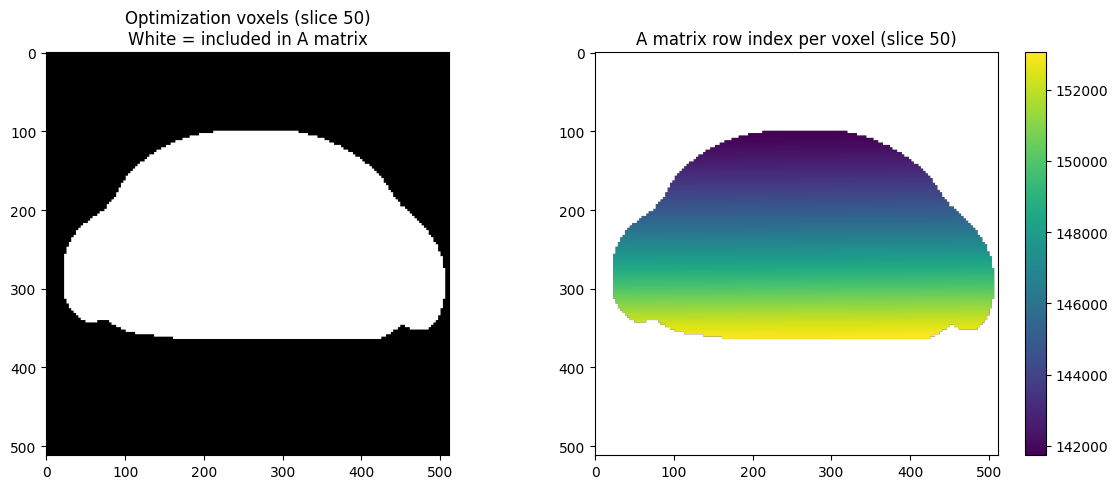

In [ ]:
# ct_to_dose_voxel_map tells you:
# For each CT voxel at position (z, y, x):
#   -1  → this voxel is NOT in the optimization grid (skip it)
#   k   → this voxel IS row k in the A matrix

# Example: what A-matrix row does CT voxel (50, 256, 256) map to?
z, y, x = 50, 256, 256
row_in_A = ct_to_dose[z, y, x]
print(f"CT voxel ({z},{y},{x}) → A matrix row {row_in_A}")

# Visualise one CT slice of the map
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: which voxels are in the opt grid (white = yes, black = no)
axes[0].imshow(ct_to_dose[50] >= 0, cmap='gray')
axes[0].set_title('Optimization voxels (slice 50)\nWhite = included in A matrix')

# Right: the actual row index values
im = axes[1].imshow(np.where(ct_to_dose[50] >= 0, ct_to_dose[50], np.nan),
                    cmap='viridis')
axes[1].set_title('A matrix row index per voxel (slice 50)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig('opt_voxel_map.png', dpi=100)
plt.show()

In [ ]:
with h5py.File('./hf_data/data/Lung_Patient_3/StructureSet_Data.h5', 'r') as f:
    mask_ptv   = f['PTV'][:]        # shape: (107, 512, 512), binary
    mask_esoph = f['ESOPHAGUS'][:]
    mask_cord  = f['CORD'][:]
    mask_lung  = f['LUNG_L'][:]
    mask_heart = f['HEART'][:]

def get_voxel_indices(mask_3d, ct_to_dose_map):
    """
    mask_3d       : binary (107, 512, 512) — 1 where structure exists
    ct_to_dose_map: int32  (107, 512, 512) — A matrix row index, -1 if not in opt grid
    Returns: 1D array of row indices into A matrix
    """
    # Voxels that are both IN the structure AND IN the opt grid
    in_structure   = mask_3d.astype(bool)
    in_opt_grid    = ct_to_dose_map >= 0
    both           = in_structure & in_opt_grid

    # Get their A matrix row indices
    row_indices    = ct_to_dose_map[both]
    return row_indices.astype(np.int32)

ptv_voxels   = get_voxel_indices(mask_ptv,   ct_to_dose)
esoph_voxels = get_voxel_indices(mask_esoph, ct_to_dose)
cord_voxels  = get_voxel_indices(mask_cord,  ct_to_dose)
lung_voxels  = get_voxel_indices(mask_lung,  ct_to_dose)
heart_voxels = get_voxel_indices(mask_heart, ct_to_dose)

print(f"PTV       : {len(ptv_voxels):,} voxels in opt grid")
print(f"Esophagus : {len(esoph_voxels):,} voxels in opt grid")
print(f"Cord      : {len(cord_voxels):,} voxels in opt grid")
print(f"Lung_L    : {len(lung_voxels):,} voxels in opt grid")
print(f"Heart     : {len(heart_voxels):,} voxels in opt grid")

PTV       : 58,845 voxels in opt grid
Esophagus : 10,885 voxels in opt grid
Cord      : 7,649 voxels in opt grid
Lung_L    : 334,755 voxels in opt grid
Heart     : 0 voxels in opt grid


In [ ]:
A_ptv   = A[ptv_voxels, :]
A_esoph = A[esoph_voxels, :]
A_cord  = A[cord_voxels, :]
A_lung  = A[lung_voxels, :]

print(f"A_ptv   : {A_ptv.shape}")
print(f"A_esoph : {A_esoph.shape}")
print(f"A_cord  : {A_cord.shape}")
print(f"A_lung  : {A_lung.shape}")

# Sanity check with unit intensity beams
x_test     = np.ones(A.shape[1], dtype=np.float32)
dose_ptv   = A_ptv   @ x_test
dose_esoph = A_esoph @ x_test
dose_cord  = A_cord  @ x_test

print(f"\nWith unit beam intensities:")
print(f"  Mean PTV dose       : {dose_ptv.mean():.4f}")
print(f"  Mean Esophagus dose : {dose_esoph.mean():.4f}")
print(f"  Mean Cord dose      : {dose_cord.mean():.4f}")

A_ptv   : (58845, 46733)
A_esoph : (10885, 46733)
A_cord  : (7649, 46733)
A_lung  : (334755, 46733)

With unit beam intensities:
  Mean PTV dose       : 67.1800
  Mean Esophagus dose : 31.2078
  Mean Cord dose      : 24.7386


In [ ]:
import json

with open('./hf_data/data/Lung_Patient_3/PlannerBeams.json') as f:
    planner = json.load(f)

print("PlannerBeams.json content:")
print(json.dumps(planner, indent=2))

PlannerBeams.json content:
{
  "IDs": [
    0,
    6,
    12,
    18,
    24,
    30,
    35
  ]
}


In [ ]:

# Extract beam IDs
if isinstance(planner, dict):
    beam_ids = planner.get('beam_ids', planner.get('BeamId', list(planner.values())[0]))
else:
    beam_ids = planner  # it's already a list

print(f"Planner selected {len(beam_ids)} beams: {beam_ids}")

# Each beam contributes a block of columns to A
# We need to know how many beamlets each beam has
beamlets_per_beam = []
for bf in sorted(beam_files):
    with h5py.File(bf, 'r') as f:
        n_beamlets_this_beam = f['inf_matrix_full'].shape[1]
        beamlets_per_beam.append(n_beamlets_this_beam)

print(f"\nBeamlets per beam (first 5): {beamlets_per_beam[:5]}")
print(f"Total beamlets: {sum(beamlets_per_beam)} (should match {A.shape[1]})")

# Build column index ranges for each beam
beam_col_start = np.cumsum([0] + beamlets_per_beam)
print(f"\nBeam 0 columns : {beam_col_start[0]} to {beam_col_start[1]-1}")
print(f"Beam 1 columns : {beam_col_start[1]} to {beam_col_start[2]-1}")

# Select only columns belonging to planner beams
planner_col_indices = np.concatenate([
    np.arange(beam_col_start[b], beam_col_start[b+1])
    for b in beam_ids
])

print(f"\nTotal planner beamlets: {len(planner_col_indices)}")

# Subset A matrix to planner beams only
A_plan     = A[:, planner_col_indices]
A_ptv_plan   = A_ptv[:,   planner_col_indices]
A_esoph_plan = A_esoph[:, planner_col_indices]
A_cord_plan  = A_cord[:,  planner_col_indices]
A_lung_plan  = A_lung[:,  planner_col_indices]

print(f"\nReduced A matrix shape : {A_plan.shape}")
print(f"A_ptv_plan shape       : {A_ptv_plan.shape}")

Planner selected 7 beams: [0, 6, 12, 18, 24, 30, 35]

Beamlets per beam (first 5): [544, 646, 646, 680, 680]
Total beamlets: 46733 (should match 46733)

Beam 0 columns : 0 to 543
Beam 1 columns : 544 to 1189

Total planner beamlets: 4420

Reduced A matrix shape : (432753, 4420)
A_ptv_plan shape       : (58845, 4420)


In [ ]:
x_test_plan = np.ones(A_plan.shape[1], dtype=np.float32)

print("Sanity check on planner-beam-only A matrix:")
print(f"  Mean PTV dose       : {(A_ptv_plan   @ x_test_plan).mean():.4f} Gy")
print(f"  Mean Esophagus dose : {(A_esoph_plan @ x_test_plan).mean():.4f} Gy")
print(f"  Mean Cord dose      : {(A_cord_plan  @ x_test_plan).mean():.4f} Gy")
print(f"\nReady for optimization ✓")
print(f"Problem size: {A_plan.shape[1]} beamlet variables, "
      f"{len(ptv_voxels)+len(esoph_voxels)+len(cord_voxels):,} constrained voxels")

Sanity check on planner-beam-only A matrix:
  Mean PTV dose       : 6.9787 Gy
  Mean Esophagus dose : 2.7286 Gy
  Mean Cord dose      : 2.2411 Gy

Ready for optimization ✓
Problem size: 4420 beamlet variables, 77,379 constrained voxels


CT keys: ['ct_hu_3d']
Best slice to visualise: 63 (has 3802 PTV voxels)


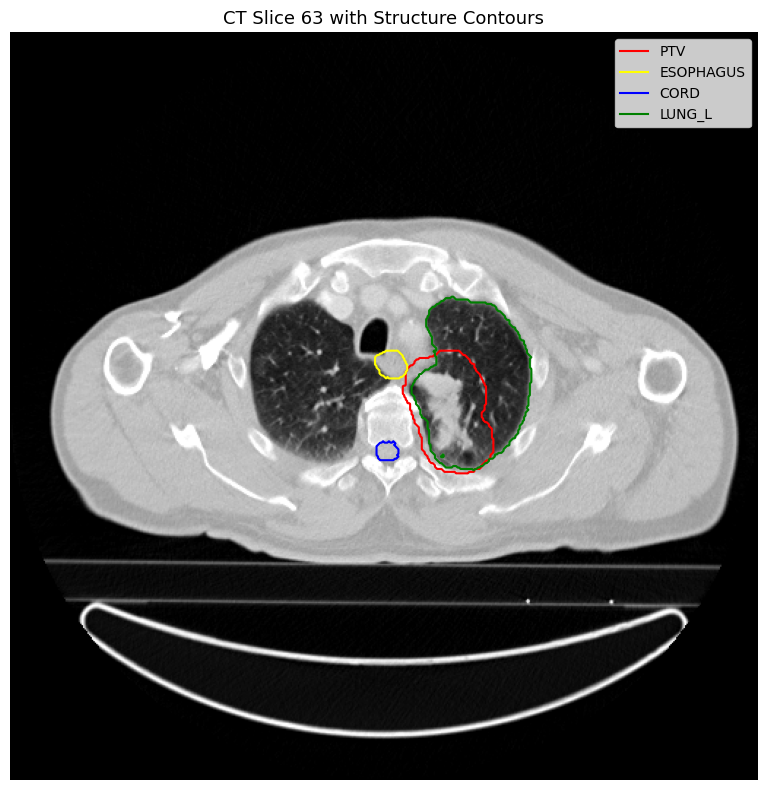

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load CT for background
with h5py.File('./hf_data/data/Lung_Patient_3/CT_Data.h5', 'r') as f:
    ct_keys = list(f.keys())
    print("CT keys:", ct_keys)
    ct_hu = f[ct_keys[0]][:]   # grab first dataset

# Pick a representative slice (middle of PTV)
# Find which slice has most PTV voxels
ptv_per_slice = mask_ptv.sum(axis=(1,2))
best_slice    = np.argmax(ptv_per_slice)
print(f"Best slice to visualise: {best_slice} "
      f"(has {ptv_per_slice[best_slice]} PTV voxels)")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(ct_hu[best_slice], cmap='gray', vmin=-1000, vmax=400)

# Overlay structures as contours
colours = {
    'PTV'      : ('red',    mask_ptv),
    'ESOPHAGUS': ('yellow', mask_esoph),
    'CORD'     : ('blue',   mask_cord),
    'LUNG_L'   : ('green',  mask_lung),
}
for name, (colour, mask) in colours.items():
    ax.contour(mask[best_slice], levels=[0.5], colors=colour, linewidths=1.5)
    ax.plot([], [], color=colour, label=name)   # legend proxy

ax.legend(loc='upper right', fontsize=10)
ax.set_title(f'CT Slice {best_slice} with Structure Contours', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('ct_structures.png', dpi=150)
plt.show()

In [ ]:
# The optimizer needs to find x such that A_ptv_plan @ x ≈ 60 Gy
# Let's understand the required scale

# If all beamlets had equal intensity k, what k achieves mean PTV dose = 60?
mean_dose_per_unit = (A_ptv_plan @ np.ones(4420)).mean()
k_required = 60.0 / mean_dose_per_unit
print(f"Mean PTV dose per unit intensity : {mean_dose_per_unit:.4f} Gy")
print(f"Uniform intensity to hit 60 Gy   : {k_required:.4f}")
print(f"So x values will be around       : {k_required:.2f} MU (monitor units)")

# Check what that uniform plan does to OARs
x_uniform = np.full(4420, k_required, dtype=np.float32)
d_ptv_unif   = A_ptv_plan   @ x_uniform
d_esoph_unif = A_esoph_plan @ x_uniform
d_cord_unif  = A_cord_plan  @ x_uniform
d_lung_unif  = A_lung_plan  @ x_uniform

print(f"\nUniform plan (x = {k_required:.2f} everywhere):")
print(f"  PTV   — mean: {d_ptv_unif.mean():.1f} Gy, "
      f"D95: {np.percentile(d_ptv_unif, 5):.1f} Gy")    # D95 = dose to 95% of volume
print(f"  Esoph — mean: {d_esoph_unif.mean():.1f} Gy, "
      f"max: {d_esoph_unif.max():.1f} Gy  (limit: 34 Gy)")
print(f"  Cord  — mean: {d_cord_unif.mean():.1f} Gy,  "
      f"max: {d_cord_unif.max():.1f} Gy  (limit: 45 Gy)")
print(f"  Lung  — mean: {d_lung_unif.mean():.1f} Gy  (limit: 20 Gy)")

Mean PTV dose per unit intensity : 6.9787 Gy
Uniform intensity to hit 60 Gy   : 8.5975
So x values will be around       : 8.60 MU (monitor units)

Uniform plan (x = 8.60 everywhere):
  PTV   — mean: 60.0 Gy, D95: 52.1 Gy
  Esoph — mean: 23.5 Gy, max: 56.7 Gy  (limit: 34 Gy)
  Cord  — mean: 19.3 Gy,  max: 50.9 Gy  (limit: 45 Gy)
  Lung  — mean: 28.0 Gy  (limit: 20 Gy)


In [ ]:
print("=" * 55)
print("  PROBLEM SUMMARY — READY FOR OPTIMIZATION")
print("=" * 55)
print(f"  Patient          : Lung_Patient_3")
print(f"  Beams selected   : 7  (IDs: 0,6,12,18,24,30,35)")
print(f"  Beamlets (vars)  : {A_plan.shape[1]:,}  ← size of x")
print(f"  Opt voxels       : {A_plan.shape[0]:,}")
print()
print(f"  OBJECTIVES:")
print(f"    F1 — PTV underdose   : {len(ptv_voxels):,} voxels, target ≥ 60 Gy")
print(f"    F2 — OAR overdose    :")
print(f"         Esophagus        : {len(esoph_voxels):,} voxels, limit 34 Gy")
print(f"         Cord             : {len(cord_voxels):,} voxels, limit 45 Gy")
print(f"         Lung mean        : {len(lung_voxels):,} voxels, limit 20 Gy")
print(f"    F3 — Spectral reg    : nuclear norm of reshaped x")
print()
print(f"  SOLVERS TO RUN:")
print(f"    1. CVXPY (convex, weighted sum) → baseline")
print(f"    2. CVXPY + spectral reg         → your contribution")

print("=" * 55)

  PROBLEM SUMMARY — READY FOR OPTIMIZATION
  Patient          : Lung_Patient_3
  Beams selected   : 7  (IDs: 0,6,12,18,24,30,35)
  Beamlets (vars)  : 4,420  ← size of x
  Opt voxels       : 432,753

  OBJECTIVES:
    F1 — PTV underdose   : 58,845 voxels, target ≥ 60 Gy
    F2 — OAR overdose    :
         Esophagus        : 10,885 voxels, limit 34 Gy
         Cord             : 7,649 voxels, limit 45 Gy
         Lung mean        : 334,755 voxels, limit 20 Gy
    F3 — Spectral reg    : nuclear norm of reshaped x

  SOLVERS TO RUN:
    1. CVXPY (convex, weighted sum) → baseline
    2. CVXPY + spectral reg         → your contribution


In [ ]:
A_plan_sparse = csr_matrix(A_plan)
#print first element in A
print(A_plan_sparse[:,:1])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1136 stored elements and shape (432753, 1)>
  Coords	Values
  (71070, 0)	0.00930735468864441
  (71071, 0)	0.009098838083446026
  (71217, 0)	0.010049262084066868
  (71218, 0)	0.009406237863004208
  (71358, 0)	0.011165016330778599
  (71359, 0)	0.009991890750825405
  (71491, 0)	0.012466391548514366
  (71492, 0)	0.0108329514041543
  (71619, 0)	0.013786199502646923
  (71620, 0)	0.011601191014051437
  (71740, 0)	0.014987125992774963
  (71741, 0)	0.012192985974252224
  (71852, 0)	0.009788076393306255
  (71853, 0)	0.01618332415819168
  (71854, 0)	0.012659389525651932
  (71943, 0)	0.010598724707961082
  (71944, 0)	0.017236463725566864
  (71945, 0)	0.012971862219274044
  (78092, 0)	0.009467112831771374
  (78249, 0)	0.009696748107671738
  (78250, 0)	0.010355169884860516
  (78408, 0)	0.010423457249999046
  (78409, 0)	0.011100530624389648
  (78567, 0)	0.01121435221284628
  (78568, 0)	0.011779844760894775
  :	:
  (130992, 0)	0.01570118963

In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# Confirm all matrices are ready
print("Problem dimensions:")
print(f"  Beamlets (x size)  : {A_plan.shape[1]}")
print(f"  PTV voxels         : {A_ptv_plan.shape[0]:,}")
print(f"  Esophagus voxels   : {A_esoph_plan.shape[0]:,}")
print(f"  Cord voxels        : {A_cord_plan.shape[0]:,}")
print(f"  Lung voxels        : {A_lung_plan.shape[0]:,}")

# Clinical dose limits
D_PTV   = 60.0   # Gy — prescription (must deliver this)
D_ESOPH = 34.0   # Gy — esophagus tolerance
D_CORD  = 45.0   # Gy — spinal cord tolerance
D_LUNG  = 20.0   # Gy — mean lung dose tolerance

n_beamlets = A_plan.shape[1]   # 4420

Problem dimensions:
  Beamlets (x size)  : 4420
  PTV voxels         : 58,845
  Esophagus voxels   : 10,885
  Cord voxels        : 7,649
  Lung voxels        : 334,755


In [ ]:
import h5py
import numpy as np

# Look inside the actual file that A comes from
beam_path = '/content/hf_data/data/Lung_Patient_3/Beams/Beam_0_Data.h5'

with h5py.File(beam_path, 'r') as f:

    # The raw sparse storage — shape (N, 3)
    raw = f['inf_matrix_sparse'][:]

    print("=" * 60)
    print("FILE: Beam_0_Data.h5  →  inf_matrix_sparse")
    print("=" * 60)
    print(f"Shape  : {raw.shape}")
    print(f"dtype  : {raw.dtype}")
    print()
    print("What each column means:")
    print("  col 0 = voxel row index  (which voxel receives this dose)")
    print("  col 1 = beamlet col index (which sub-beam delivers it)")
    print("  col 2 = dose value in Gy  (at unit beam intensity)")
    print()
    print("First 5 nonzero entries:")
    print(f"  {'voxel':>8}  {'beamlet':>8}  {'dose(Gy)':>10}")
    print(f"  {'-'*8}  {'-'*8}  {'-'*10}")
    for row in raw[:5]:
        print(f"  {int(row[0]):>8}  {int(row[1]):>8}  {row[2]:>10.6f}")

    print()
    print(f"Total nonzero entries : {len(raw):,}")
    print(f"Max voxel index       : {int(raw[:,0].max()):,}  (out of 432,753)")
    print(f"Max beamlet index     : {int(raw[:,1].max()):,}")
    print(f"Max dose value        : {raw[:,2].max():.6f} Gy")
    print(f"Min dose value (>0)   : {raw[raw[:,2]>0, 2].min():.6f} Gy")

FILE: Beam_0_Data.h5  →  inf_matrix_sparse
Shape  : (1098259, 3)
dtype  : float32

What each column means:
  col 0 = voxel row index  (which voxel receives this dose)
  col 1 = beamlet col index (which sub-beam delivers it)
  col 2 = dose value in Gy  (at unit beam intensity)

First 5 nonzero entries:
     voxel   beamlet    dose(Gy)
  --------  --------  ----------
     71070         0    0.009307
     71071         0    0.009099
     71217         0    0.010049
     71218         0    0.009406
     71358         0    0.011165

Total nonzero entries : 1,098,259
Max voxel index       : 432,752  (out of 432,753)
Max beamlet index     : 543
Max dose value        : 0.774311 Gy
Min dose value (>0)   : 0.008999 Gy


In [ ]:
print("=" * 60)
print("ASSEMBLED A MATRIX  (all 72 beams combined)")
print("=" * 60)
print(f"Shape   : {A.shape}")
print(f"         ↑       ↑")
print(f"    432,753   46,733")
print(f"    voxels    beamlets")
print()
print(f"Type    : {type(A)}")
print(f"Format  : CSR sparse (Compressed Sparse Row)")
print(f"Memory  : {A.data.nbytes / 1e6:.1f} MB")
print(f"Nonzeros: {A.nnz:,}")
print(f"Density : {100 * A.nnz / (A.shape[0]*A.shape[1]):.4f}% filled")
print()

# Print 5 actual nonzero values from A
cx = A.tocoo()   # convert to COO to easily access row, col, data
print("5 sample nonzero entries from A:")
print(f"  {'voxel(row)':>12}  {'beamlet(col)':>14}  {'dose(Gy)':>10}")
print(f"  {'-'*12}  {'-'*14}  {'-'*10}")
for i in range(5):
    print(f"  {cx.row[i]:>12}  {cx.col[i]:>14}  {cx.data[i]:>10.6f}")

print()
print("Interpretation of first entry:")
r, c, v = cx.row[0], cx.col[0], cx.data[0]
print(f"  Voxel {r} receives {v:.6f} Gy from beamlet {c} at intensity 1.0")

ASSEMBLED A MATRIX  (all 72 beams combined)
Shape   : (432753, 46733)
         ↑       ↑
    432,753   46,733
    voxels    beamlets

Type    : <class 'scipy.sparse._csr.csr_matrix'>
Format  : CSR sparse (Compressed Sparse Row)
Memory  : 439.8 MB
Nonzeros: 109,950,260
Density : 0.5437% filled

5 sample nonzero entries from A:
    voxel(row)    beamlet(col)    dose(Gy)
  ------------  --------------  ----------
         40073            8865    0.009352
         40196            6812    0.010047
         40196            8112    0.010432
         40196            8866    0.010059
         40196            9621    0.009927

Interpretation of first entry:
  Voxel 40073 receives 0.009352 Gy from beamlet 8865 at intensity 1.0


In [ ]:
print("=" * 60)
print("A_plan  (7 planner beams only — used in optimization)")
print("=" * 60)
print(f"Shape   : {A_plan.shape}")
print(f"         ↑      ↑")
print(f"    432,753   4,420")
print(f"    voxels    beamlets (7 beams × ~631 each)")
print()

cx_plan = A_plan.tocoo()
print("5 sample entries from A_plan:")
print(f"  {'voxel':>8}  {'beamlet':>8}  {'dose(Gy)':>10}")
print(f"  {'-'*8}  {'-'*8}  {'-'*10}")
for i in range(5):
    print(f"  {cx_plan.row[i]:>8}  {cx_plan.col[i]:>8}  {cx_plan.data[i]:>10.6f}")

A_plan  (7 planner beams only — used in optimization)
Shape   : (432753, 4420)
         ↑      ↑
    432,753   4,420
    voxels    beamlets (7 beams × ~631 each)

5 sample entries from A_plan:
     voxel   beamlet    dose(Gy)
  --------  --------  ----------
     40196      1278    0.010432
     40197      1277    0.009279
     40197      1278    0.009264
     40198      1277    0.009043
     40323      1279    0.011314


In [ ]:
print("=" * 60)
print("STRUCTURE SUB-MATRICES")
print("(rows of A_plan selected by structure voxel indices)")
print("=" * 60)

for name, mat, voxels in [
    ("A_ptv_plan",   A_ptv_plan,   ptv_voxels),
    ("A_esoph_plan", A_esoph_plan, esoph_voxels),
    ("A_cord_plan",  A_cord_plan,  cord_voxels),
]:
    cx_s = mat.tocoo()
    print(f"\n{name}:")
    print(f"  Shape : {mat.shape}  ← ({mat.shape[0]} structure voxels × 4420 beamlets)")
    print(f"  These are rows {voxels[:3]} ... of A_plan")
    print(f"  5 sample entries:")
    print(f"    {'struct_voxel':>14}  {'beamlet':>8}  {'dose(Gy)':>10}")
    print(f"    {'-'*14}  {'-'*8}  {'-'*10}")
    for i in range(min(5, len(cx_s.data))):
        print(f"    {cx_s.row[i]:>14}  {cx_s.col[i]:>8}  {cx_s.data[i]:>10.6f}")

    # Show what unit beams give
    d_unit = mat @ np.ones(mat.shape[1], dtype=np.float32)
    print(f"  Dose stats at unit intensity (x = all 1s):")
    print(f"    mean={d_unit.mean():.4f}  min={d_unit.min():.4f}  max={d_unit.max():.4f} Gy")

STRUCTURE SUB-MATRICES
(rows of A_plan selected by structure voxel indices)

A_ptv_plan:
  Shape : (58845, 4420)  ← (58845 structure voxels × 4420 beamlets)
  These are rows [123007 123007 123007] ... of A_plan
  5 sample entries:
      struct_voxel   beamlet    dose(Gy)
    --------------  --------  ----------
                 0        17    0.012858
                 0        18    0.016549
                 0        19    0.014658
                 0        20    0.009407
                 0        47    0.012600
  Dose stats at unit intensity (x = all 1s):
    mean=6.9787  min=5.5175  max=8.9898 Gy

A_esoph_plan:
  Shape : (10885, 4420)  ← (10885 structure voxels × 4420 beamlets)
  These are rows [5546 5542 5542] ... of A_plan
  5 sample entries:
      struct_voxel   beamlet    dose(Gy)
    --------------  --------  ----------
              1497         4    0.011988
              1497         5    0.011573
              1497       553    0.018294
              1497       554    0.0267

## Optimization Setup — Sparse Matrices (no dense conversion)

We keep everything in sparse format. `todense()` would allocate ~1 GB and crash Colab.
Instead we work directly on `.data` (the nonzero values only).

In [ ]:
import numpy as np
import scipy.sparse as sp
import scs
import time
import warnings
warnings.filterwarnings('ignore')

# Clinical dose limits (Gy)
D_PTV   = 60.0
D_ESOPH = 34.0
D_CORD  = 45.0
D_LUNG  = 20.0

# Cast to float64 sparse — NO .todense() call
A_ptv_sp   = A_ptv_plan.astype(np.float64)
A_esoph_sp = A_esoph_plan.astype(np.float64)
A_cord_sp  = A_cord_plan.astype(np.float64)
A_lung_sp  = A_lung_plan.astype(np.float64)

print('Sparse matrices ready (no dense conversion)')
for name, m in [('A_ptv', A_ptv_sp), ('A_esoph', A_esoph_sp),
                ('A_cord', A_cord_sp), ('A_lung', A_lung_sp)]:
    mb = (m.data.nbytes + m.indices.nbytes + m.indptr.nbytes) / 1e6
    print(f'  {name:<10} shape={m.shape}  sparse size={mb:.1f} MB')


Sparse matrices ready (no dense conversion)
  A_ptv      shape=(58845, 4420)  sparse size=92.0 MB
  A_esoph    shape=(10885, 4420)  sparse size=5.9 MB
  A_cord     shape=(7649, 4420)  sparse size=3.2 MB
  A_lung     shape=(334755, 4420)  sparse size=299.6 MB


## Solve WITHOUT Spectral Regularization

**Why direct SCS and not CVXPY?**  
CVXPY internally converts problems to COO format and allocates dense float64 arrays during canonicalization — this causes a MemoryError on large problems like ours.  
Calling `scs.SCS()` directly accepts CSC sparse matrices and stays sparse throughout.

**Linearisation of max(v, 0):**  
We introduce slack variables t and write:  
`min sum(t)  s.t.  t >= violation,  t >= 0`  
This converts the nonsmooth hinge loss into a standard linear cone program.

In [ ]:
import numpy as np
import scipy.sparse as sp
import scs
import time

def solve_no_spectral(A_ptv, A_esoph, A_cord, A_lung, w1=1.0, w2=2.0):
    t0 = time.time()

    # Constants (Assumed based on your snippet, adjust as needed)
    D_PTV = 60.0
    D_ESOPH = 45.0
    D_CORD = 30.0
    D_LUNG = 20.0

    n  = A_ptv.shape[1]    # Beamlets
    nP = A_ptv.shape[0]    # PTV voxels
    nE = A_esoph.shape[0]  # Esoph voxels
    nC = A_cord.shape[0]   # Cord voxels
    nL = A_lung.shape[0]   # Lung voxels

    # Variable layout: z = [x(n), t_ptv(nP), t_esoph(nE), t_cord(nC)]
    n_vars = n + nP + nE + nC
    print(f'  Variables: {n_vars:,}')

    # 1. Objective Vector c
    c = np.zeros(n_vars)
    c[n:n+nP]           = w1 / nP  # PTV underdose
    c[n+nP:n+nP+nE]     = w2 / nE  # Esoph overdose
    c[n+nP+nE:n_vars]   = w2 / nC  # Cord overdose

    rows_ub = []
    rhs_ub = []

    # 2. Constraints
    # (A) PTV underdose: -A_ptv*x - t_ptv <= -D_PTV
    A1 = sp.hstack([-A_ptv, -sp.eye(nP),
                    sp.csr_matrix((nP, nE)), sp.csr_matrix((nP, nC))], format='csr')
    rows_ub.append(A1)
    rhs_ub.append(-D_PTV * np.ones(nP))

    # (B) Esoph overdose: A_esoph*x - t_esoph <= D_ESOPH
    A2 = sp.hstack([A_esoph, sp.csr_matrix((nE, nP)),
                    -sp.eye(nE), sp.csr_matrix((nE, nC))], format='csr')
    rows_ub.append(A2)
    rhs_ub.append(D_ESOPH * np.ones(nE))

    # (C) Cord overdose: A_cord*x - t_cord <= D_CORD
    A3 = sp.hstack([A_cord, sp.csr_matrix((nC, nP)),
                    sp.csr_matrix((nC, nE)), -sp.eye(nC)], format='csr')
    rows_ub.append(A3)
    rhs_ub.append(D_CORD * np.ones(nC))

    # (D) Lung mean dose: (1/nL) * 1^T * A_lung * x <= D_LUNG
    lung_row_vec = (np.ones(nL) @ A_lung) / nL
    A4 = sp.csr_matrix(np.hstack([lung_row_vec, np.zeros(nP + nE + nC)]).reshape(1, -1))
    rows_ub.append(A4)
    rhs_ub.append(np.array([D_LUNG]))

    # (E) Non-negativity: -z <= 0 (for all n_vars)
    A5 = -sp.eye(n_vars, format='csr')
    rows_ub.append(A5)
    rhs_ub.append(np.zeros(n_vars))

    # Stack everything
    A_ub = sp.vstack(rows_ub, format='csc')
    b_ub = np.concatenate(rhs_ub)

    # Final Dimension Check
    m_constraints = A_ub.shape[0]
    if A_ub.shape[1] != n_vars:
        raise ValueError(f"Column mismatch: A has {A_ub.shape[1]} cols, but c has {n_vars}")
    if len(b_ub) != m_constraints:
        raise ValueError(f"Row mismatch: A has {m_constraints} rows, but b has {len(b_ub)}")

    print(f'  Constraints: {m_constraints:,}  |  A_ub nnz: {A_ub.nnz:,}')

    # Call SCS
    data = {'c': c.astype(np.float64),
            'A': A_ub.astype(np.float64),
            'b': b_ub.astype(np.float64)}

    # 'l' is the size of the linear inequality cone (number of rows in A)
    cone = {'l': m_constraints}

    solver = scs.SCS(data, cone, eps=1e-4, max_iters=5000, verbose=False)
    sol = solver.solve()

    elapsed = time.time() - t0
    xv = sol['x']

    if xv is not None:
        x_opt = xv[:n]
        # Calculate penalty metrics
        F1 = float(np.mean(np.maximum(D_PTV - A_ptv @ x_opt, 0)))
        dose_e = A_esoph @ x_opt
        dose_c = A_cord @ x_opt
        F2 = float(np.mean(np.maximum(dose_e - D_ESOPH, 0)) +
                   np.mean(np.maximum(dose_c - D_CORD, 0)))
    else:
        x_opt = None
        F1, F2 = np.nan, np.nan

    return {'x': x_opt, 'status': sol['info']['status'],
            'F1': F1, 'F2': F2, 'F_spectral': 0.0,
            'solve_time': elapsed, 'label': 'No Spectral Reg'}

# Example execution (assuming your sparse matrices exist)
# r_no_spec = solve_no_spectral(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)

In [ ]:
import scs, scipy.sparse as sp, numpy as np

print("SCS version:", scs.__version__)

# Minimal smoke-test — if this fails, SCS itself is broken
A_tiny = sp.eye(2, format='csc')
b_tiny = np.array([1.0, 1.0])
c_tiny = np.array([1.0, 1.0])
try:
    sol = scs.solve({'A': A_tiny, 'b': b_tiny, 'c': c_tiny}, {'l': 2}, verbose=False)
    print("Functional API: OK")
except Exception as e:
    print("Functional API FAILED:", e)

try:
    solver = scs.SCS({'A': A_tiny, 'b': b_tiny, 'c': c_tiny}, {'l': 2}, verbose=False)
    sol = solver.solve()
    print("Class API: OK")
except Exception as e:
    print("Class API FAILED:", e)

SCS version: 3.2.11
Functional API: OK
Class API: OK


In [ ]:
for name, M in [('A_ptv', A_ptv_sp), ('A_esoph', A_esoph_sp),
                ('A_cord', A_cord_sp), ('A_lung', A_lung_sp)]:
    print(f"{name}: dtype={M.dtype}, has_nan={np.isnan(M.data).any()}, "
          f"has_inf={np.isinf(M.data).any()}, shape={M.shape}")

A_ptv: dtype=float64, has_nan=False, has_inf=False, shape=(58845, 4420)
A_esoph: dtype=float64, has_nan=False, has_inf=False, shape=(10885, 4420)
A_cord: dtype=float64, has_nan=False, has_inf=False, shape=(7649, 4420)
A_lung: dtype=float64, has_nan=False, has_inf=False, shape=(334755, 4420)


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Install (run once, then restart runtime)
# ════════════════════════════════════════════════════════════════
!pip install -q  cuosqp
!pip install -q clarabel  # fallback for spectral

import subprocess, sys
print(subprocess.run(['nvcc', '--version'], capture_output=True, text=True).stdout)
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU name       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")

ERROR: Could not find a version that satisfies the requirement cuosqp (from versions: none)
ERROR: No matching distribution found for cuosqp
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

CUDA available : True
GPU name       : Tesla T4


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Imports + shared config
# ════════════════════════════════════════════════════════════════
import numpy as np
import scipy.sparse as sp
import cvxpy as cp
import torch
import time

D_PTV, D_ESOPH, D_CORD, D_LUNG = 60.0, 45.0, 30.0, 20.0

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Solving device : {DEVICE}")
print(f"CVXPY solvers  : {cp.installed_solvers()}")

Solving device : cuda
CVXPY solvers  : ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — GPU utility: sparse matrix → torch CUDA tensor
# ════════════════════════════════════════════════════════════════
def sp_to_torch(M, device, dtype=torch.float32):
    """Convert scipy sparse → torch sparse COO on device."""
    M = M.astype(np.float32).tocoo()
    idx = torch.tensor(np.vstack([M.row, M.col]), dtype=torch.long)
    val = torch.tensor(M.data, dtype=dtype)
    return torch.sparse_coo_tensor(idx, val, M.shape, device=device).coalesce()


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — NO-SPECTRAL: cuOSQP on GPU
# ════════════════════════════════════════════════════════════════
def solve_no_spectral_gpu(A_ptv, A_esoph, A_cord, A_lung,
                           w1=1.0, w2=2.0):
    """
    Uses cuOSQP which runs the entire ADMM solver on the GPU.
    Falls back to CLARABEL (CPU) if cuOSQP is not available.
    """
    t0 = time.time()

    n  = A_ptv.shape[1]
    nP = A_ptv.shape[0]
    nE = A_esoph.shape[0]
    nC = A_cord.shape[0]
    nL = A_lung.shape[0]

    # Cast to float64 for CVXPY (cuOSQP handles the GPU transfer internally)
    A_ptv   = A_ptv.astype(np.float64).tocsr()
    A_esoph = A_esoph.astype(np.float64).tocsr()
    A_cord  = A_cord.astype(np.float64).tocsr()
    A_lung  = A_lung.astype(np.float64).tocsr()

    x       = cp.Variable(n,  nonneg=True)
    t_ptv   = cp.Variable(nP, nonneg=True)
    t_esoph = cp.Variable(nE, nonneg=True)
    t_cord  = cp.Variable(nC, nonneg=True)

    prob = cp.Problem(
        cp.Minimize(
            (w1 / nP) * cp.sum(t_ptv)   +
            (w2 / nE) * cp.sum(t_esoph) +
            (w2 / nC) * cp.sum(t_cord)
        ),
        [
            D_PTV   - A_ptv   @ x <= t_ptv,
            A_esoph @ x - D_ESOPH <= t_esoph,
            A_cord  @ x - D_CORD  <= t_cord,
            cp.sum(A_lung @ x) / nL <= D_LUNG,
        ]
    )

    print(f'  Variables   : {n + nP + nE + nC:,}')
    print(f'  Constraints : {nP + nE + nC + 1:,}')

    # Try cuOSQP (GPU) first, fall back to CLARABEL (CPU)
    try:
        prob.solve(
            solver=cp.OSQP,
            eps_abs=1e-4,
            eps_rel=1e-4,
            max_iter=10000,
            warm_starting=True,
            gpu=True,           # cuOSQP flag — ignored by vanilla OSQP
            verbose=False,
        )
        used = 'cuOSQP-GPU'
    except Exception as e:
        print(f'  cuOSQP failed ({e}), falling back to CLARABEL')
        prob.solve(solver=cp.CLARABEL,
                   eps_abs=1e-4, eps_rel=1e-4,
                   max_iter=5000, verbose=False)
        used = 'CLARABEL-CPU'

    elapsed = time.time() - t0
    xv = x.value

    if xv is not None:
        F1 = float(np.mean(np.maximum(D_PTV   - A_ptv   @ xv, 0)))
        F2 = float(np.mean(np.maximum(A_esoph @ xv - D_ESOPH, 0)) +
                   np.mean(np.maximum(A_cord  @ xv - D_CORD,  0)))
    else:
        F1 = F2 = np.nan

    print(f'  Solver used : {used}')
    return dict(x=xv, status=prob.status, F1=F1, F2=F2,
                solve_time=elapsed, label=used)

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — SPECTRAL: PyTorch on GPU  (nuclear norm via SVD)
# ════════════════════════════════════════════════════════════════
def solve_with_spectral_gpu(A_ptv, A_esoph, A_cord, A_lung,
                             n_beams, bpb,
                             w1=1.0, w2=2.0, lam=0.05,
                             lr=5e-3, max_iter=4000, tol=1e-7):
    """
    Projected gradient descent on GPU.
    Nuclear norm computed via torch.linalg.svdvals — fully GPU-native.
    Constraints enforced via quadratic penalty (rho) + projection.
    """
    t0 = time.time()

    nb      = n_beams
    min_bpb = min(bpb)
    n_unif  = nb * min_bpb      # beamlets that form the matrix X
    n       = A_ptv.shape[1]
    nP      = A_ptv.shape[0]
    nE      = A_esoph.shape[0]
    nC      = A_cord.shape[0]
    nL      = A_lung.shape[0]

    print(f'  Device      : {DEVICE}')
    print(f'  X shape     : ({nb} × {min_bpb})')
    print(f'  n_unif/n    : {n_unif}/{n}  lam={lam}')

    # Move dose matrices to GPU
    Ap = sp_to_torch(A_ptv,   DEVICE)
    Ae = sp_to_torch(A_esoph, DEVICE)
    Ac = sp_to_torch(A_cord,  DEVICE)
    Al = sp_to_torch(A_lung,  DEVICE)

    # Unconstrained param; softplus gives smooth x >= 0
    x_raw = torch.zeros(n, device=DEVICE, requires_grad=True)

    optimizer = torch.optim.Adam([x_raw], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_iter, eta_min=1e-5)

    # Penalty coefficients — increased over time (continuation)
    rho_lung = 5.0
    rho_esoph = 2.0
    rho_cord  = 2.0

    prev_loss = float('inf')
    history   = []

    for it in range(max_iter):
        optimizer.zero_grad()

        x = torch.nn.functional.softplus(x_raw)

        # Dose calculations (sparse matmul on GPU)
        d_ptv   = torch.mv(Ap, x)
        d_esoph = torch.mv(Ae, x)
        d_cord  = torch.mv(Ac, x)
        d_lung  = torch.mv(Al, x)

        # Objective terms
        F1     = torch.mean(torch.clamp(D_PTV   - d_ptv,   min=0))
        F2_e   = torch.mean(torch.clamp(d_esoph - D_ESOPH, min=0))
        F2_c   = torch.mean(torch.clamp(d_cord  - D_CORD,  min=0))

        # Nuclear norm of beamlet matrix X
        X      = x[:n_unif].reshape(nb, min_bpb)
        nuc    = torch.linalg.svdvals(X).sum()   # GPU SVD

        # Lung constraint as quadratic penalty
        lung_viol = torch.clamp(d_lung.mean() - D_LUNG, min=0)

        loss = (
            w1 * F1 +
            w2 * (F2_e + F2_c) +
            lam * nuc +
            rho_lung  * lung_viol ** 2 +
            rho_esoph * F2_e ** 2 +
            rho_cord  * F2_c ** 2
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Ramp up penalties every 500 iters
        if it > 0 and it % 500 == 0:
            rho_lung  = min(rho_lung  * 2, 200.0)
            rho_esoph = min(rho_esoph * 2, 100.0)
            rho_cord  = min(rho_cord  * 2, 100.0)
            print(f'    iter {it:4d} | loss={loss.item():.5f} | '
                  f'F1={F1.item():.4f} | nuc={nuc.item():.4f} | '
                  f'lung_viol={lung_viol.item():.4f}')

        # Convergence
        delta = abs(prev_loss - loss.item())
        history.append(loss.item())
        if delta < tol and it > 500:
            print(f'    Converged at iter {it}  (Δloss={delta:.2e})')
            break
        prev_loss = loss.item()

    elapsed = time.time() - t0
    xv = torch.nn.functional.softplus(x_raw).detach().cpu().numpy()

    F1  = float(np.mean(np.maximum(D_PTV   - A_ptv   @ xv, 0)))
    F2  = float(np.mean(np.maximum(A_esoph @ xv - D_ESOPH, 0)) +
                np.mean(np.maximum(A_cord  @ xv - D_CORD,  0)))
    nuc = float(np.linalg.norm(xv[:n_unif].reshape(nb, min_bpb), 'nuc'))

    return dict(x=xv, status='solved', F1=F1, F2=F2,
                F_spectral=nuc, solve_time=elapsed,
                label=f'PyTorch-GPU-lam={lam}', history=history)

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Run everything
# ════════════════════════════════════════════════════════════════

# ── No-spectral ──────────────────────────────────────────────────
print('='*55)
print('NO-SPECTRAL (cuOSQP GPU)')
print('='*55)
r_no = solve_no_spectral_gpu(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
print(f"  Status  : {r_no['status']}")
print(f"  F1 PTV  : {r_no['F1']:.4f} Gy/voxel")
print(f"  Time    : {r_no['solve_time']:.1f} s")

# ── Spectral ─────────────────────────────────────────────────────
planner_bpb = [beamlets_per_beam[b] for b in beam_ids]
print(f'\nBeamlets per beam : {planner_bpb}')

for lam in [0.05, 0.20]:
    print(f'\n{"="*55}')
    print(f'SPECTRAL lam={lam} (PyTorch GPU)')
    print('='*55)
    r = solve_with_spectral_gpu(
        A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
        n_beams=len(beam_ids), bpb=planner_bpb, lam=lam)
    print(f"  Status   : {r['status']}")
    print(f"  F1 PTV   : {r['F1']:.4f}  F2 OAR : {r['F2']:.4f}")
    print(f"  Nuc norm : {r['F_spectral']:.4f}")
    print(f"  Time     : {r['solve_time']:.1f} s")

NO-SPECTRAL (cuOSQP GPU)
  Variables   : 81,799
  Constraints : 77,380
  cuOSQP failed (Unrecognized settings ['gpu']), falling back to CLARABEL


TypeError: Clarabel: unrecognized solver setting 'eps_abs'.

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Check exact versions first
# ════════════════════════════════════════════════════════════════
import clarabel, cvxpy as cp, torch
print(f"clarabel : {clarabel.__version__}")
print(f"cvxpy    : {cp.__version__}")
print(f"torch    : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Solvers  : {cp.installed_solvers()}")

# Check correct CLARABEL setting names for YOUR version
import clarabel
s = clarabel.DefaultSettings()
print(dir(s))  # this will show the exact attribute names available

clarabel : 0.11.1
cvxpy    : 1.6.7
torch    : 2.10.0+cu128
CUDA     : True
Solvers  : ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']
['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'chordal_decomposition_compact', 'chordal_decomposition_complete_dual', 'chordal_decomposition_enable', 'chordal_decomposition_merge_method', 'default', 'direct_kkt_solver', 'direct_solve_method', 'dynamic_regularization_delta', 'dynamic_regularization_enable', 'dynamic_regularization_eps', 'equilibrate_enable', 'equilibrate_max_iter', 'equilibrate_max_scaling', 'equilibrate_min_scaling', 'input_sparse_dropzeros', 'iterative_refinement_abstol', 'iterative_refinement_enable', 'itera

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Install cuOSQP properly for Colab
# ════════════════════════════════════════════════════════════════
import subprocess, sys

# Step 1: check CUDA version (cuOSQP wheel must match)
result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
print(result.stdout)

# Step 2: install cuOSQP — Colab T4 is usually CUDA 11.x or 12.x
!pip install cuosqp -q

# Step 3: verify it registered with CVXPY
import importlib, cvxpy as cp
importlib.reload(cp)
print("Solvers after install:", cp.installed_solvers())
print("cuOSQP available:", 'OSQP' in cp.installed_solvers())

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

ERROR: Could not find a version that satisfies the requirement cuosqp (from versions: none)
ERROR: No matching distribution found for cuosqp
Solvers after install: ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']
cuOSQP available: True


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Correct solver kwargs that work across versions
# ════════════════════════════════════════════════════════════════
import clarabel, cvxpy as cp

def get_clarabel_kwargs():
    """
    CLARABEL renamed settings across versions.
    Detect the right names by inspecting DefaultSettings directly.
    """
    s = clarabel.DefaultSettings()
    kwargs = {}

    # Tolerance: 'eps_abs' (old) vs 'equilibrate_enable' era vs current
    for tol_name in ['eps_abs', 'tol_gap_abs', 'tol_feas']:
        if hasattr(s, tol_name):
            kwargs[tol_name] = 1e-4
            break

    for reltol_name in ['eps_rel', 'tol_gap_rel']:
        if hasattr(s, reltol_name):
            kwargs[reltol_name] = 1e-4
            break

    for iter_name in ['max_iter', 'max_iters']:
        if hasattr(s, iter_name):
            kwargs[iter_name] = 5000
            break

    print(f"  CLARABEL kwargs detected: {kwargs}")
    return kwargs

CLARABEL_KW = get_clarabel_kwargs()
print("Will use:", CLARABEL_KW)

  CLARABEL kwargs detected: {'tol_gap_abs': 0.0001, 'tol_gap_rel': 0.0001, 'max_iter': 5000}
Will use: {'tol_gap_abs': 0.0001, 'tol_gap_rel': 0.0001, 'max_iter': 5000}


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Robust solver picker (GPU → CPU fallback chain)
# ════════════════════════════════════════════════════════════════
import numpy as np
import scipy.sparse as sp
import cvxpy as cp
import torch, time

D_PTV, D_ESOPH, D_CORD, D_LUNG = 60.0, 45.0, 30.0, 20.0

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

def _build_problem(A_ptv, A_esoph, A_cord, A_lung, w1, w2):
    """Builds CVXPY problem, returns (prob, x). Shared by all solvers."""
    n  = A_ptv.shape[1]
    nP = A_ptv.shape[0]
    nE = A_esoph.shape[0]
    nC = A_cord.shape[0]
    nL = A_lung.shape[0]

    A_ptv   = A_ptv.astype(np.float64).tocsr()
    A_esoph = A_esoph.astype(np.float64).tocsr()
    A_cord  = A_cord.astype(np.float64).tocsr()
    A_lung  = A_lung.astype(np.float64).tocsr()

    x       = cp.Variable(n,  nonneg=True)
    t_ptv   = cp.Variable(nP, nonneg=True)
    t_esoph = cp.Variable(nE, nonneg=True)
    t_cord  = cp.Variable(nC, nonneg=True)

    prob = cp.Problem(
        cp.Minimize(
            (w1 / nP) * cp.sum(t_ptv)   +
            (w2 / nE) * cp.sum(t_esoph) +
            (w2 / nC) * cp.sum(t_cord)
        ),
        [
            D_PTV   - A_ptv   @ x <= t_ptv,
            A_esoph @ x - D_ESOPH <= t_esoph,
            A_cord  @ x - D_CORD  <= t_cord,
            cp.sum(A_lung @ x) / nL <= D_LUNG,
        ]
    )
    return prob, x, n, nP, nE, nC, A_ptv, A_esoph, A_cord


def solve_no_spectral_gpu(A_ptv, A_esoph, A_cord, A_lung, w1=1.0, w2=2.0):
    t0 = time.time()
    prob, x, n, nP, nE, nC, Ap, Ae, Ac = _build_problem(
        A_ptv, A_esoph, A_cord, A_lung, w1, w2)

    print(f'  Variables   : {n + nP + nE + nC:,}')
    print(f'  Constraints : {nP + nE + nC + 1:,}')

    # ── Solver chain: cuOSQP → OSQP → CLARABEL ──────────────────
    solved_with = None

    # 1. Try cuOSQP (true GPU solver)
    if 'OSQP' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.OSQP, eps_abs=1e-4, eps_rel=1e-4,
                       max_iter=10000, warm_starting=True,
                       gpu=True, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                solved_with = 'cuOSQP-GPU'
        except Exception as e:
            print(f'  cuOSQP-GPU failed: {e}')

    # 2. Try vanilla OSQP (CPU, but fast ADMM)
    if solved_with is None and 'OSQP' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.OSQP, eps_abs=1e-4, eps_rel=1e-4,
                       max_iter=10000, warm_starting=True, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                solved_with = 'OSQP-CPU'
        except Exception as e:
            print(f'  OSQP-CPU failed: {e}')

    # 3. CLARABEL with version-safe kwargs
    if solved_with is None and 'CLARABEL' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.CLARABEL, verbose=False, **CLARABEL_KW)
            if prob.status in ['optimal', 'optimal_inaccurate',
                               'solved', 'solved_inaccurate']:
                solved_with = 'CLARABEL-CPU'
        except Exception as e:
            print(f'  CLARABEL failed: {e}')

    # 4. SCS absolute fallback
    if solved_with is None:
        prob.solve(solver=cp.SCS, eps=1e-4, max_iters=5000, verbose=False)
        solved_with = 'SCS-CPU'

    elapsed = time.time() - t0
    xv = x.value

    if xv is not None:
        F1 = float(np.mean(np.maximum(D_PTV  - Ap @ xv, 0)))
        F2 = float(np.mean(np.maximum(Ae @ xv - D_ESOPH, 0)) +
                   np.mean(np.maximum(Ac @ xv - D_CORD,  0)))
    else:
        F1 = F2 = np.nan

    print(f'  Solved with : {solved_with}')
    return dict(x=xv, status=prob.status, F1=F1, F2=F2,
                solve_time=elapsed, label=solved_with)

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — PyTorch GPU spectral (no CVXPY, no version issues)
# ════════════════════════════════════════════════════════════════
def sp_to_torch(M, device, dtype=torch.float32):
    M = M.astype(np.float32).tocoo()
    idx = torch.tensor(np.vstack([M.row, M.col]), dtype=torch.long)
    val = torch.tensor(M.data, dtype=dtype)
    return torch.sparse_coo_tensor(idx, val, M.shape,
                                   device=device).coalesce()

def solve_with_spectral_gpu(A_ptv, A_esoph, A_cord, A_lung,
                             n_beams, bpb, w1=1.0, w2=2.0, lam=0.05,
                             lr=5e-3, max_iter=4000, tol=1e-7):
    t0 = time.time()
    nb, min_bpb = n_beams, min(bpb)
    n_unif = nb * min_bpb
    n      = A_ptv.shape[1]
    nP, nE, nC, nL = (A_ptv.shape[0], A_esoph.shape[0],
                      A_cord.shape[0],  A_lung.shape[0])

    print(f'  Device  : {DEVICE}')
    print(f'  X shape : ({nb} × {min_bpb})  lam={lam}')

    Ap = sp_to_torch(A_ptv,   DEVICE)
    Ae = sp_to_torch(A_esoph, DEVICE)
    Ac = sp_to_torch(A_cord,  DEVICE)
    Al = sp_to_torch(A_lung,  DEVICE)

    x_raw = torch.zeros(n, device=DEVICE, requires_grad=True)
    opt   = torch.optim.Adam([x_raw], lr=lr)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=max_iter, eta_min=1e-5)

    rho_lung = rho_oar = 5.0

    for it in range(max_iter):
        opt.zero_grad()
        x = torch.nn.functional.softplus(x_raw)

        F1    = torch.mean(torch.clamp(D_PTV   - torch.mv(Ap, x), min=0))
        F2_e  = torch.mean(torch.clamp(torch.mv(Ae, x) - D_ESOPH, min=0))
        F2_c  = torch.mean(torch.clamp(torch.mv(Ac, x) - D_CORD,  min=0))
        l_vio = torch.clamp(torch.mv(Al, x).mean() - D_LUNG, min=0)
        nuc   = torch.linalg.svdvals(x[:n_unif].reshape(nb, min_bpb)).sum()

        loss = (w1*F1 + w2*(F2_e+F2_c) + lam*nuc
                + rho_lung*l_vio**2 + rho_oar*(F2_e**2 + F2_c**2))
        loss.backward()
        opt.step()
        sch.step()

        if it > 0 and it % 500 == 0:
            rho_lung = min(rho_lung * 2, 200.0)
            rho_oar  = min(rho_oar  * 2, 100.0)
            print(f'    iter {it:4d} | loss={loss.item():.5f} | '
                  f'F1={F1.item():.4f} | nuc={nuc.item():.3f} | '
                  f'lung_viol={l_vio.item():.4f}')

        if abs(loss.item()) < tol and it > 500:
            print(f'    Converged at iter {it}')
            break

    elapsed = time.time() - t0
    xv  = torch.nn.functional.softplus(x_raw).detach().cpu().numpy()
    F1  = float(np.mean(np.maximum(D_PTV   - A_ptv   @ xv, 0)))
    F2  = float(np.mean(np.maximum(A_esoph @ xv - D_ESOPH, 0)) +
                np.mean(np.maximum(A_cord  @ xv - D_CORD,  0)))
    nuc = float(np.linalg.norm(xv[:n_unif].reshape(nb, min_bpb), 'nuc'))

    return dict(x=xv, status='solved', F1=F1, F2=F2,
                F_spectral=nuc, solve_time=elapsed,
                label=f'PyTorch-{DEVICE}-lam={lam}')

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Run
# ════════════════════════════════════════════════════════════════
print('='*55)
print('NO-SPECTRAL')
print('='*55)
r_no = solve_no_spectral_gpu(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
print(f"  Status : {r_no['status']}")
print(f"  F1 PTV : {r_no['F1']:.4f} Gy/voxel")
print(f"  Time   : {r_no['solve_time']:.1f} s")

planner_bpb = [beamlets_per_beam[b] for b in beam_ids]
for lam in [0.05, 0.20]:
    print(f'\n{"="*55}')
    print(f'SPECTRAL lam={lam}')
    print('='*55)
    r = solve_with_spectral_gpu(
            A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
            n_beams=len(beam_ids), bpb=planner_bpb, lam=lam)
    print(f"  Status   : {r['status']}")
    print(f"  F1 PTV   : {r['F1']:.4f}  F2 OAR : {r['F2']:.4f}")
    print(f"  Nuc norm : {r['F_spectral']:.4f}")
    print(f"  Time     : {r['solve_time']:.1f} s")

NO-SPECTRAL
  Variables   : 81,799
  Constraints : 77,380
  cuOSQP-GPU failed: Unrecognized settings ['gpu']
  Solved with : OSQP-CPU
  Status : optimal
  F1 PTV : 0.0013 Gy/voxel
  Time   : 261.6 s

SPECTRAL lam=0.05
  Device  : cuda
  X shape : (7 × 544)  lam=0.05
    iter  500 | loss=50.48267 | F1=45.6170 | nuc=97.314 | lung_viol=0.0000
    iter 1000 | loss=42.73557 | F1=34.3003 | nuc=168.706 | lung_viol=0.0000
    iter 1500 | loss=36.27719 | F1=24.7516 | nuc=230.512 | lung_viol=0.0000
    iter 2000 | loss=31.41148 | F1=17.5250 | nuc=277.616 | lung_viol=0.0000
    iter 2500 | loss=28.45129 | F1=12.9964 | nuc=308.726 | lung_viol=0.0000
    iter 3000 | loss=27.04212 | F1=10.7600 | nuc=325.041 | lung_viol=0.0000
    iter 3500 | loss=26.53537 | F1=9.9426 | nuc=331.113 | lung_viol=0.0000
  Status   : solved
  F1 PTV   : 9.8104  F2 OAR : 0.0119
  Nuc norm : 332.1022
  Time     : 750.8 s

SPECTRAL lam=0.2
  Device  : cuda
  X shape : (7 × 544)  lam=0.2
    iter  500 | loss=59.69437 | F1=53

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Run
# ════════════════════════════════════════════════════════════════
print('='*55)
#print('NO-SPECTRAL')
print('='*55)
#r_no = solve_no_spectral_gpu(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
#print(f"  Status : {r_no['status']}")
#print(f"  F1 PTV : {r_no['F1']:.4f} Gy/voxel")
#print(f"  Time   : {r_no['solve_time']:.1f} s")

planner_bpb = [beamlets_per_beam[b] for b in beam_ids]
for lam in [0.001]:
    print(f'\n{"="*55}')
    print(f'SPECTRAL lam={lam}')
    print('='*55)
    r = solve_with_spectral_gpu(
            A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
            n_beams=len(beam_ids), bpb=planner_bpb, lam=lam)
    print(f"  Status   : {r['status']}")
    print(f"  F1 PTV   : {r['F1']:.4f}  F2 OAR : {r['F2']:.4f}")
    print(f"  Nuc norm : {r['F_spectral']:.4f}")
    print(f"  Time     : {r['solve_time']:.1f} s")


SPECTRAL lam=0.001
  Device  : cuda
  X shape : (7 × 544)  lam=0.001
    iter  500 | loss=40.04947 | F1=39.8703 | nuc=179.131 | lung_viol=0.0000
    iter 1000 | loss=22.59573 | F1=22.2597 | nuc=335.966 | lung_viol=0.0000
    iter 1500 | loss=9.48312 | F1=8.9110 | nuc=567.100 | lung_viol=0.0097
    iter 2000 | loss=3.28335 | F1=2.5284 | nuc=744.719 | lung_viol=0.0056
    iter 2500 | loss=2.00172 | F1=1.1811 | nuc=810.720 | lung_viol=0.0024
    iter 3000 | loss=1.65659 | F1=0.8128 | nuc=835.608 | lung_viol=0.0011
    iter 3500 | loss=1.55501 | F1=0.7037 | nuc=844.215 | lung_viol=0.0009
  Status   : solved
  F1 PTV   : 0.6863  F2 OAR : 0.0031
  Nuc norm : 845.6677
  Time     : 745.9 s


evaluation

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Auto-detect available results
# ════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

D_PTV, D_ESOPH, D_CORD, D_LUNG = 60.0, 45.0, 30.0, 20.0

# Auto-collect whichever results exist in namespace
_candidates = {
    'No Spectral'   : 'r_no',
    'Spectral 0.05' : 'r_spec_low',
    'Spectral 0.20' : 'r_spec_high',
}
RESULTS = {}
for label, varname in _candidates.items():
    try:
        r = eval(varname)
        if r.get('x') is not None:
            r.setdefault('label', label)
            RESULTS[label] = r
            print(f"  ✓  {label:20s}  status={r.get('status','?')}  "
                  f"F1={r.get('F1', np.nan):.4f}  "
                  f"time={r.get('solve_time', np.nan):.1f}s")
        else:
            print(f"  ✗  {label:20s}  (no solution)")
    except NameError:
        print(f"  –  {label:20s}  (not in namespace, skipping)")

print(f"\nEvaluating {len(RESULTS)} result(s): {list(RESULTS.keys())}")
planner_bpb = [beamlets_per_beam[b] for b in beam_ids]
nb          = len(beam_ids)
COLORS      = ['#00c8ff', '#ff6b6b', '#a8ff78', '#ffd166']

  ✓  No Spectral           status=optimal  F1=0.0013  time=261.6s
  –  Spectral 0.05         (not in namespace, skipping)
  –  Spectral 0.20         (not in namespace, skipping)

Evaluating 1 result(s): ['No Spectral']


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Scalar metrics
# ════════════════════════════════════════════════════════════════
def compute_metrics(r, A_ptv, A_esoph, A_cord, A_lung, nb, bpb):
    x = np.maximum(r['x'], 0)
    min_bpb = min(bpb)
    n_unif  = nb * min_bpb

    d_ptv   = np.asarray(A_ptv   @ x).ravel()
    d_esoph = np.asarray(A_esoph @ x).ravel()
    d_cord  = np.asarray(A_cord  @ x).ravel()
    d_lung  = np.asarray(A_lung  @ x).ravel()

    svs      = np.linalg.svd(x[:n_unif].reshape(nb, min_bpb),
                              compute_uv=False)
    nuc_norm = svs.sum()
    eff_rank = (svs.sum()**2) / ((svs**2).sum() + 1e-12)

    return {
        'label'        : r.get('label', '?'),
        'status'       : r.get('status', '?'),
        'solve_time_s' : round(r.get('solve_time', np.nan), 1),
        # PTV
        'D95_ptv'      : round(np.percentile(d_ptv, 5),  3),
        'D05_ptv'      : round(np.percentile(d_ptv, 95), 3),
        'Dmean_ptv'    : round(d_ptv.mean(), 3),
        'HI'           : round((np.percentile(d_ptv,95) -
                                np.percentile(d_ptv, 5)) / D_PTV, 4),
        'CI_proxy_%'   : round(np.mean(d_ptv >= 0.95*D_PTV)*100, 2),
        'F1_underdose' : round(float(np.mean(np.maximum(D_PTV-d_ptv, 0))), 4),
        # OARs
        'Dmean_esoph'  : round(d_esoph.mean(), 3),
        'Dmax_esoph'   : round(d_esoph.max(),  3),
        'Dmean_cord'   : round(d_cord.mean(),  3),
        'Dmax_cord'    : round(d_cord.max(),   3),
        'Dmean_lung'   : round(d_lung.mean(),  3),
        'V20_lung_%'   : round(np.mean(d_lung >= 20.0)*100, 2),
        'F2_overdose'  : round(float(np.mean(np.maximum(d_esoph-D_ESOPH,0)) +
                                     np.mean(np.maximum(d_cord -D_CORD, 0))), 4),
        'lung_viol'    : round(float(max(d_lung.mean()-D_LUNG, 0)), 4),
        # Plan structure
        'sparsity_%'   : round(np.mean(x < 1e-3)*100, 2),
        'total_MU'     : round(x.sum(), 2),
        'nuc_norm'     : round(nuc_norm, 4),
        'eff_rank'     : round(eff_rank, 3),
    }

rows = [compute_metrics(r, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
                        nb, planner_bpb)
        for r in RESULTS.values()]
df = pd.DataFrame(rows).set_index('label')

# ── Clinical summary table ───────────────────────────────────────
groups = {
    'PTV Coverage' : ['D95_ptv','D05_ptv','Dmean_ptv',
                      'HI','CI_proxy_%','F1_underdose'],
    'OAR Sparing'  : ['Dmean_esoph','Dmax_esoph','Dmean_cord',
                      'Dmax_cord','Dmean_lung','V20_lung_%',
                      'F2_overdose','lung_viol'],
    'Plan Quality' : ['sparsity_%','total_MU','nuc_norm',
                      'eff_rank','solve_time_s'],
}
col_w = max(18, max(len(l) for l in df.index) + 2)
header = f"{'METRIC':<24}" + "".join(f"{l:>{col_w}}" for l in df.index)
print('\n' + '═'*len(header))
print(header)
print('═'*len(header))
for grp, keys in groups.items():
    print(f'\n  ── {grp} ──')
    for k in keys:
        if k not in df.columns:
            continue
        row = "".join(f"{str(df.loc[l,k]):>{col_w}}" for l in df.index)
        print(f"  {k:<24}{row}")
print('═'*len(header))


══════════════════════════════════════════
METRIC                            OSQP-CPU
══════════════════════════════════════════

  ── PTV Coverage ──
  D95_ptv                              62.58
  D05_ptv                            104.494
  Dmean_ptv                             78.9
  HI                                  0.6986
  CI_proxy_%                           99.99
  F1_underdose                        0.0013

  ── OAR Sparing ──
  Dmean_esoph                          9.559
  Dmax_esoph                          45.029
  Dmean_cord                           7.462
  Dmax_cord                             30.0
  Dmean_lung                            20.0
  V20_lung_%                           31.79
  F2_overdose                            0.0
  lung_viol                           0.0002

  ── Plan Quality ──
  sparsity_%                           48.33
  total_MU                          32783.07
  nuc_norm                         3318.5498
  eff_rank                             6

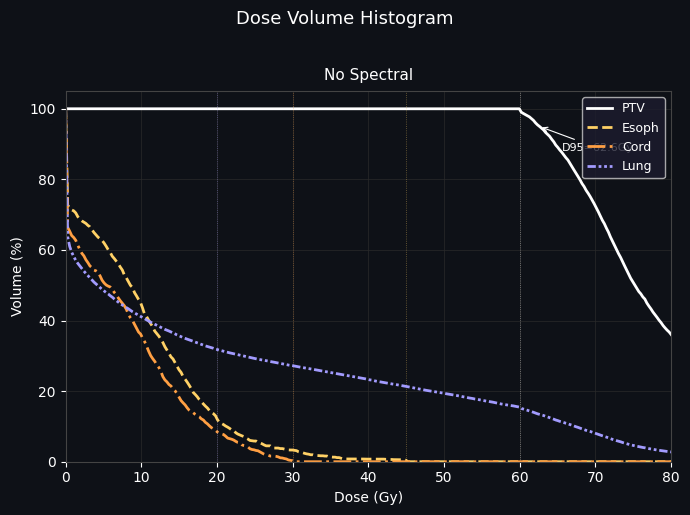

Saved → dvh.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — DVH
# ════════════════════════════════════════════════════════════════
def plot_dvh(results_dict, A_ptv, A_esoph, A_cord, A_lung,
             dose_max=80.0, n_bins=300):

    bins = np.linspace(0, dose_max, n_bins)
    structs = [
        ('PTV',   A_ptv,   D_PTV,   '-',              '#ffffff'),
        ('Esoph', A_esoph, D_ESOPH, '--',              '#ffd166'),
        ('Cord',  A_cord,  D_CORD,  '-.',              '#ff9f43'),
        ('Lung',  A_lung,  D_LUNG,  (0,(3,1,1,1,1,1)),'#a29bfe'),
    ]
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 5), sharey=True,
                             facecolor='#0e1117')

    # single result → axes is not a list
    if n == 1:
        axes = [axes]

    for ax, (label, r), col in zip(axes, results_dict.items(), COLORS):
        x = np.maximum(r['x'], 0)
        for sname, A, limit, ls, sc in structs:
            dose = np.asarray(A @ x).ravel()
            dvh  = np.array([(dose >= d).mean()*100 for d in bins])
            ax.plot(bins, dvh, color=sc, linestyle=ls,
                    linewidth=2, label=sname)
            ax.axvline(limit, color=sc, linewidth=0.6,
                       linestyle=':', alpha=0.45)

        ax.set_facecolor('#0e1117')
        ax.set_title(label, color='white', fontsize=11, pad=8)
        ax.set_xlabel('Dose (Gy)', color='white', fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel('Volume (%)', color='white', fontsize=10)
        ax.tick_params(colors='white')
        ax.set_xlim(0, dose_max)
        ax.set_ylim(0, 105)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.grid(True, color='#2a2a2a', linewidth=0.5)
        ax.legend(facecolor='#1c1c2e', labelcolor='white',
                  fontsize=9, loc='upper right')

        # Annotate D95 on PTV curve
        dose_ptv = np.asarray(A_ptv @ x).ravel()
        d95 = np.percentile(dose_ptv, 5)
        ax.annotate(f'D95={d95:.1f}Gy',
                    xy=(d95, 95), xytext=(d95+3, 88),
                    color='white', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='white',
                                   lw=0.8))

    plt.suptitle('Dose Volume Histogram', color='white',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('dvh.png', dpi=150, bbox_inches='tight',
                facecolor='#0e1117')
    plt.show()
    print("Saved → dvh.png")

plot_dvh(RESULTS, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)

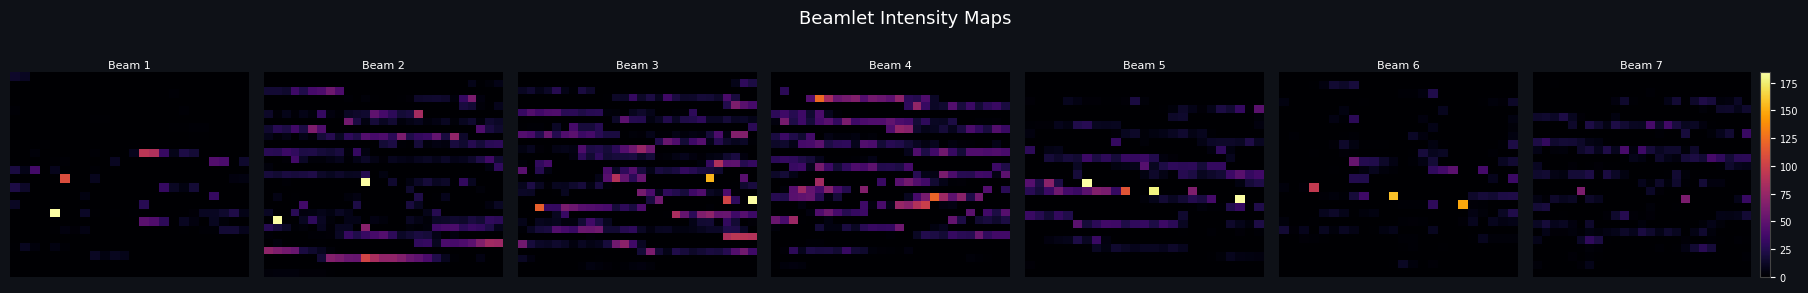

Saved → beamlet_maps.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Beamlet intensity maps
# ════════════════════════════════════════════════════════════════
def plot_beamlet_maps(results_dict, bpb, cmap='inferno'):
    n_res = len(results_dict)
    nb    = len(bpb)
    fig, axes = plt.subplots(n_res, nb,
                             figsize=(nb*2.6, n_res*2.8),
                             facecolor='#0e1117',
                             squeeze=False)

    for row, (label, r) in enumerate(results_dict.items()):
        x      = np.maximum(r['x'], 0)
        offset = 0
        # global vmax across beams for this result (consistent colorscale)
        vmax = max(x[offset:offset+b].max() + 1e-9 for b in bpb)

        for col, n_beamlets in enumerate(bpb):
            ax       = axes[row, col]
            beam_x   = x[offset:offset + n_beamlets]
            offset  += n_beamlets
            side     = int(np.ceil(np.sqrt(n_beamlets)))
            padded   = np.zeros(side * side)
            padded[:n_beamlets] = beam_x
            img = padded.reshape(side, side)

            im = ax.imshow(img, cmap=cmap, aspect='auto',
                           vmin=0, vmax=vmax,
                           interpolation='nearest')
            ax.set_title(f'Beam {col+1}', color='white', fontsize=8, pad=3)
            ax.axis('off')

            # colorbar only on last beam per row
            if col == nb - 1:
                cb = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
                cb.ax.tick_params(colors='white', labelsize=7)
                cb.outline.set_edgecolor('#444')

        axes[row, 0].set_ylabel(label, color='white', fontsize=9,
                                rotation=90, labelpad=4)

    plt.suptitle('Beamlet Intensity Maps', color='white',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('beamlet_maps.png', dpi=150, bbox_inches='tight',
                facecolor='#0e1117')
    plt.show()
    print("Saved → beamlet_maps.png")

plot_beamlet_maps(RESULTS, planner_bpb)

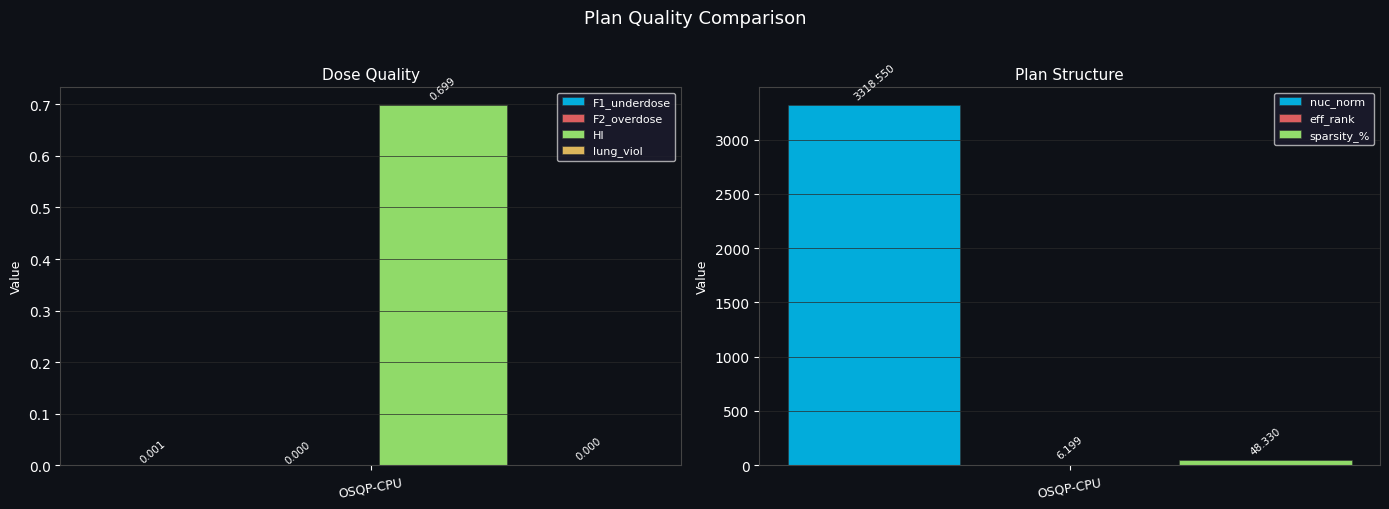

Saved → comparison_bars.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Bar chart: F1 / F2 / nuclear norm / HI / eff_rank
# ════════════════════════════════════════════════════════════════
def plot_comparison_bars(df_metrics):
    metric_groups = {
        'Dose Quality'   : ['F1_underdose', 'F2_overdose', 'HI', 'lung_viol'],
        'Plan Structure' : ['nuc_norm', 'eff_rank', 'sparsity_%'],
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0e1117')
    labels = df_metrics.index.tolist()
    x_base = np.arange(len(labels))

    for ax, (grp_name, metrics) in zip(axes, metric_groups.items()):
        n_m   = len(metrics)
        width = 0.7 / n_m
        ax.set_facecolor('#0e1117')

        for i, metric in enumerate(metrics):
            if metric not in df_metrics.columns:
                continue
            vals  = df_metrics[metric].astype(float).values
            col   = COLORS[i % len(COLORS)]
            bars  = ax.bar(x_base + i*width - (n_m-1)*width/2,
                           vals, width*0.88,
                           label=metric, color=col, alpha=0.85,
                           edgecolor='#333', linewidth=0.5)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + ax.get_ylim()[1]*0.01,
                        f'{val:.3f}', ha='center', va='bottom',
                        color='white', fontsize=7.5, rotation=40)

        ax.set_xticks(x_base)
        ax.set_xticklabels(labels, color='white', fontsize=9, rotation=10)
        ax.tick_params(colors='white')
        ax.set_title(grp_name, color='white', fontsize=11)
        ax.set_ylabel('Value', color='white', fontsize=9)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.legend(facecolor='#1c1c2e', labelcolor='white',
                  fontsize=8, loc='upper right')
        ax.grid(axis='y', color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Plan Quality Comparison', color='white',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight',
                facecolor='#0e1117')
    plt.show()
    print("Saved → comparison_bars.png")

plot_comparison_bars(df)

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Convergence curve  (PyTorch results only)
# ════════════════════════════════════════════════════════════════
def plot_convergence(results_dict):
    has_history = {l: r for l, r in results_dict.items()
                   if r.get('history') is not None}

    if not has_history:
        print("No convergence history found.\n"
              "History is only stored for PyTorch GPU spectral runs.\n"
              "OSQP/CLARABEL results don't expose per-iteration loss.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                                    facecolor='#0e1117')
    for ax in (ax1, ax2):
        ax.set_facecolor('#0e1117')

    for (label, r), col in zip(has_history.items(), COLORS):
        hist = np.array(r['history'])
        iters = np.arange(len(hist))

        # linear scale
        ax1.plot(iters, hist, color=col, linewidth=1.5,
                 label=label, alpha=0.9)
        # log scale — clip negatives for log
        hist_pos = np.where(hist > 0, hist, np.nan)
        ax2.plot(iters, hist_pos, color=col, linewidth=1.5,
                 label=label, alpha=0.9)

    for ax, scale, title in [
        (ax1, 'linear', 'Loss — linear scale'),
        (ax2, 'log',    'Loss — log scale'),
    ]:
        ax.set_yscale(scale)
        ax.set_title(title, color='white', fontsize=11)
        ax.set_xlabel('Iteration', color='white', fontsize=9)
        ax.set_ylabel('Loss', color='white', fontsize=9)
        ax.tick_params(colors='white')
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=9)
        ax.grid(color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Convergence Curves (PyTorch GPU)', color='white',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('convergence.png', dpi=150, bbox_inches='tight',
                facecolor='#0e1117')
    plt.show()
    print("Saved → convergence.png")

plot_convergence(RESULTS)

No convergence history found.
History is only stored for PyTorch GPU spectral runs.
OSQP/CLARABEL results don't expose per-iteration loss.


In [ ]:
!pip install portpy cvxpy pymoo scipy matplotlib numpy h5py datasets
!pip install cuosqp clarabel torch --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.6/134.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found exist

ERROR: Could not find a version that satisfies the requirement cuosqp (from versions: none)
ERROR: No matching distribution found for cuosqp


Fetching ... files: 0it [00:00, ?it/s]

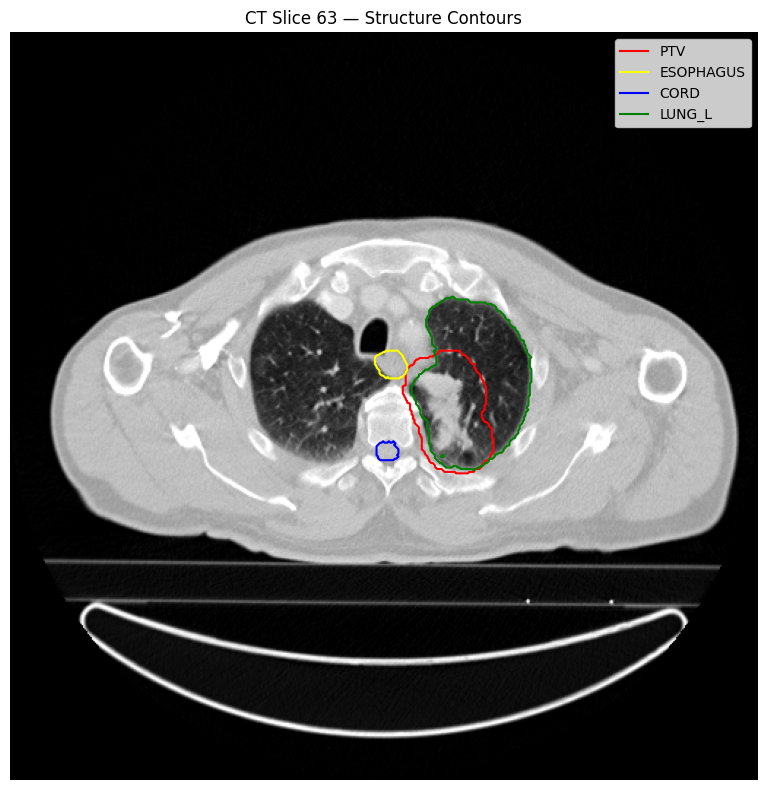

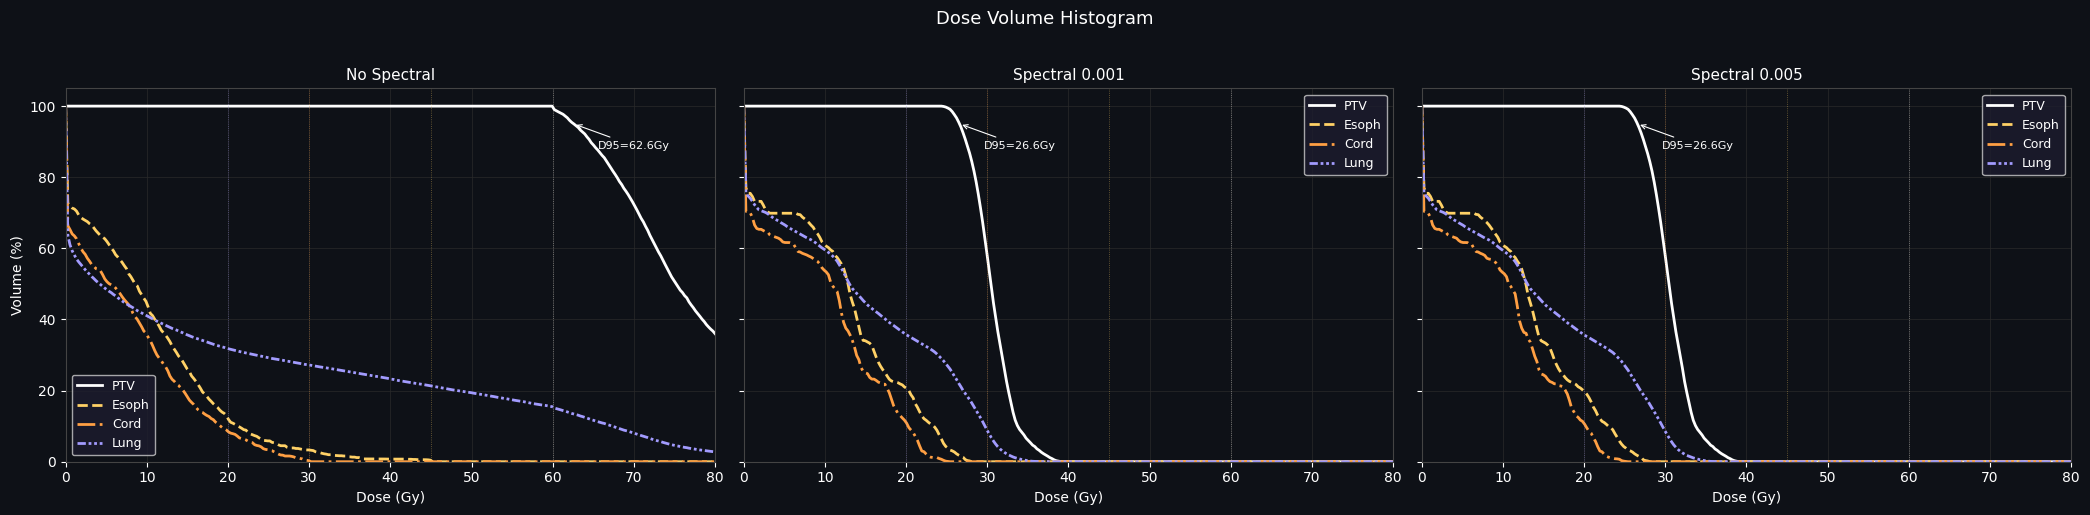

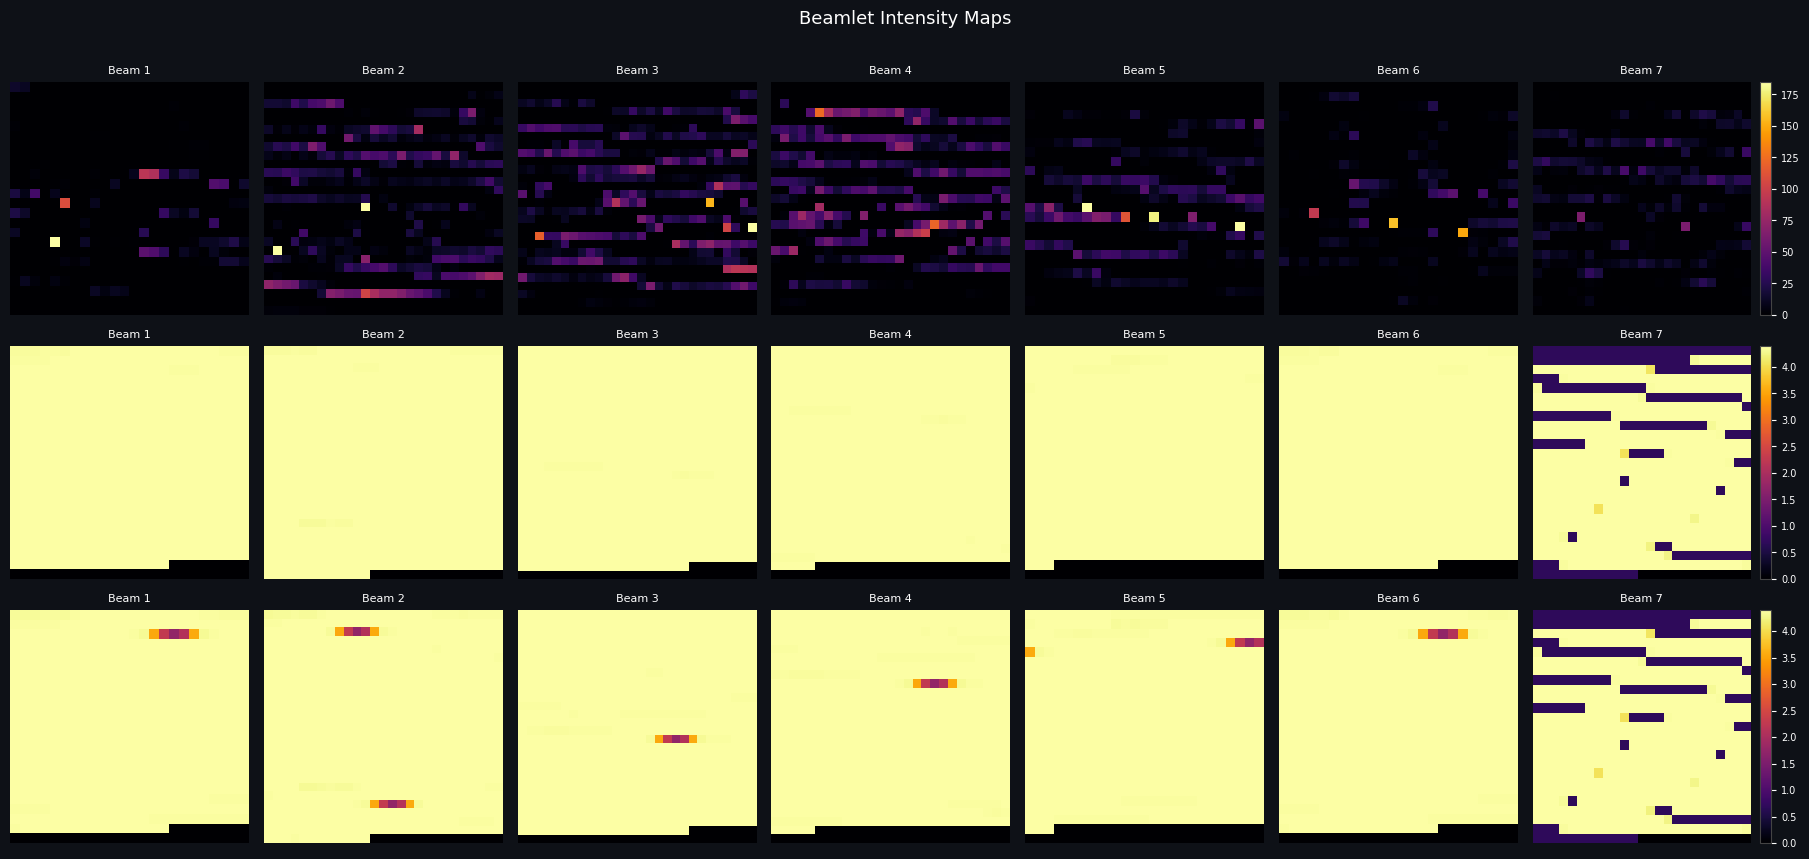

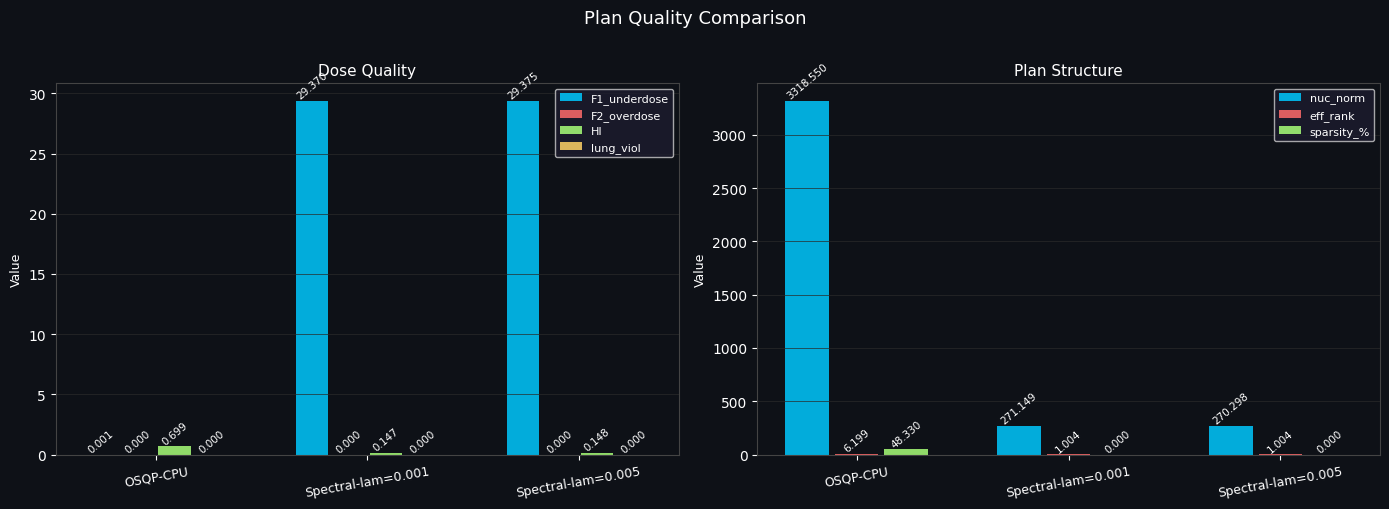

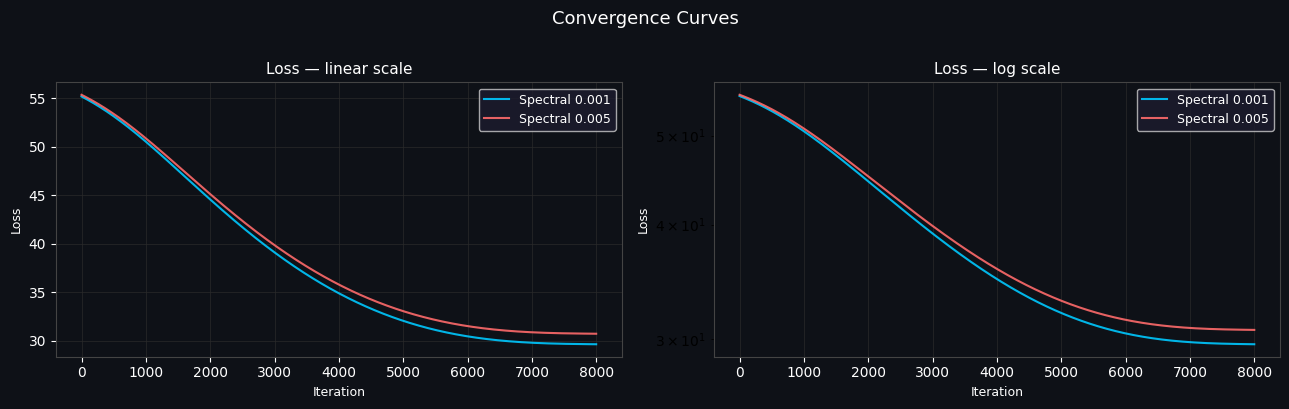


════════════════════════════════════════════════════════════════════════════════════
METRIC                              OSQP-CPU  Spectral-lam=0.001  Spectral-lam=0.005
════════════════════════════════════════════════════════════════════════════════════

  -- PTV Coverage --
  D95_ptv                                62.58              26.588              26.566
  D05_ptv                              104.494              35.424              35.421
  Dmean_ptv                               78.9               30.63              30.625
  HI                                    0.6986              0.1473              0.1476
  CI_proxy_%                             99.99                 0.0                 0.0
  F1_underdose                          0.0013               29.37             29.3746

  -- OAR Sparing --
  Dmean_esoph                            9.559              11.448               11.37
  Dmax_esoph                            45.029              28.271              28.268
  Dme

In [ ]:
# =============================================================================
# Radiation Treatment Planning Optimisation
# Patient: Lung_Patient_3  |  Dataset: PortPy (HuggingFace)
# =============================================================================

# ── SECTION 1: INSTALLATION ──────────────────────────────────────────────────
# Run this cell first, then restart the Colab runtime before continuing.

# !pip install portpy cvxpy pymoo scipy matplotlib numpy h5py datasets
# !pip install cuosqp clarabel torch --upgrade


# ── SECTION 2: IMPORTS ───────────────────────────────────────────────────────

import os
import json
import h5py
import numpy as np
import scipy.sparse as sp
from scipy.sparse import coo_matrix, hstack
import cvxpy as cp
import torch
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# Clinical dose limits (Gy)
D_PTV   = 60.0   # tumour must receive at least this
D_ESOPH = 45.0   # oesophagus hard cap per voxel
D_CORD  = 30.0   # spinal cord hard cap per voxel
D_LUNG  = 20.0   # lung mean dose limit

# Solver device (GPU if available)
DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)


# ── SECTION 3: DATA DOWNLOAD ─────────────────────────────────────────────────
# Downloads Lung_Patient_3 from HuggingFace PortPy dataset.
# Only runs once — subsequent runs use the local cache.

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="PortPy-Project/PortPy_Dataset",
    repo_type="dataset",
    allow_patterns="data/Lung_Patient_3/*",
    local_dir="./hf_data"
)


# ── SECTION 4: BUILD DOSE INFLUENCE MATRIX A ─────────────────────────────────
# Each beam has its own HDF5 file containing a sparse dose matrix.
# We stack all beams horizontally to get the full A matrix:
#   A shape: (432,753 voxels  x  46,733 beamlets across 72 beams)
# Each entry A[i,j] = dose received at voxel i if beamlet j fires at 1 MU.

beam_dir   = './hf_data/data/Lung_Patient_3/Beams'
beam_files = sorted([
    os.path.join(beam_dir, f)
    for f in os.listdir(beam_dir)
    if f.endswith('_Data.h5')
])

# Find consistent number of voxels from first beam
with h5py.File(beam_files[0], 'r') as f:
    n_voxels = f['inf_matrix_full'].shape[0]

# Build sparse COO matrix for each beam then stack horizontally
A_blocks = []
beamlets_per_beam = []

for bf in sorted(beam_files):
    with h5py.File(bf, 'r') as f:
        coo_data = f['inf_matrix_sparse'][:]       # shape: (nnz, 3) — row, col, value
        n_cols   = f['inf_matrix_full'].shape[1]   # number of beamlets in this beam

        rows = coo_data[:, 0].astype(np.int32)
        cols = coo_data[:, 1].astype(np.int32)
        vals = coo_data[:, 2].astype(np.float32)

        A_beam = coo_matrix((vals, (rows, cols)), shape=(n_voxels, n_cols)).tocsr()
        A_blocks.append(A_beam)
        beamlets_per_beam.append(n_cols)

# Full A matrix: all 72 beams combined
A = hstack(A_blocks, format='csr')


# ── SECTION 5: LOAD CT-TO-DOSE VOXEL MAP ─────────────────────────────────────
# The CT scan has 107x512x512 voxels, but only a subset are used in optimisation.
# ct_to_dose_voxel_map maps each CT voxel to its row in A:
#   -1  → voxel not in optimisation grid (skip it)
#   k   → voxel is row k in A

with h5py.File('./hf_data/data/Lung_Patient_3/OptimizationVoxels_Data.h5', 'r') as f:
    ct_to_dose = f['ct_to_dose_voxel_map'][:]   # shape: (107, 512, 512)


# ── SECTION 6: LOAD STRUCTURE MASKS AND EXTRACT VOXEL INDICES ────────────────
# Each structure (PTV, ESOPHAGUS, etc.) is stored as a binary 3D mask.
# We find which of those voxels are also in the optimisation grid,
# then get their A-matrix row indices.

with h5py.File('./hf_data/data/Lung_Patient_3/StructureSet_Data.h5', 'r') as f:
    mask_ptv   = f['PTV'][:]
    mask_esoph = f['ESOPHAGUS'][:]
    mask_cord  = f['CORD'][:]
    mask_lung  = f['LUNG_L'][:]
    mask_heart = f['HEART'][:]


def get_voxel_indices(mask_3d, ct_to_dose_map):
    """
    Returns the A-matrix row indices for voxels that are:
    (1) inside the structure mask, AND
    (2) inside the optimisation grid (ct_to_dose_map >= 0)
    """
    in_structure = mask_3d.astype(bool)
    in_opt_grid  = ct_to_dose_map >= 0
    both         = in_structure & in_opt_grid
    return ct_to_dose_map[both].astype(np.int32)


ptv_voxels   = get_voxel_indices(mask_ptv,   ct_to_dose)
esoph_voxels = get_voxel_indices(mask_esoph, ct_to_dose)
cord_voxels  = get_voxel_indices(mask_cord,  ct_to_dose)
lung_voxels  = get_voxel_indices(mask_lung,  ct_to_dose)

# Sub-matrices: rows of A corresponding to each structure
A_ptv   = A[ptv_voxels,   :]
A_esoph = A[esoph_voxels, :]
A_cord  = A[cord_voxels,  :]
A_lung  = A[lung_voxels,  :]


# ── SECTION 7: SELECT PLANNER BEAMS AND RESTRICT A ───────────────────────────
# A clinical planner selected 7 specific beams out of 72 available.
# We restrict the A matrix to only those 7 beams' columns.

with open('./hf_data/data/Lung_Patient_3/PlannerBeams.json') as f:
    planner = json.load(f)

beam_ids = planner if isinstance(planner, list) else list(planner.values())[0]

# Column index range for each beam in A
beam_col_start = np.cumsum([0] + beamlets_per_beam)

# Collect column indices belonging to the 7 planner beams
planner_col_indices = np.concatenate([
    np.arange(beam_col_start[b], beam_col_start[b+1])
    for b in beam_ids
])

# Restrict all matrices to planner beams only
A_ptv_plan   = A_ptv[:,   planner_col_indices]
A_esoph_plan = A_esoph[:, planner_col_indices]
A_cord_plan  = A_cord[:,  planner_col_indices]
A_lung_plan  = A_lung[:,  planner_col_indices]

# Cast to float64 sparse for solvers
A_ptv_sp   = A_ptv_plan.astype(np.float64)
A_esoph_sp = A_esoph_plan.astype(np.float64)
A_cord_sp  = A_cord_plan.astype(np.float64)
A_lung_sp  = A_lung_plan.astype(np.float64)

planner_bpb = [beamlets_per_beam[b] for b in beam_ids]


# ── SECTION 8: VISUALISE CT WITH STRUCTURE CONTOURS ──────────────────────────

with h5py.File('./hf_data/data/Lung_Patient_3/CT_Data.h5', 'r') as f:
    ct_hu = f[list(f.keys())[0]][:]

best_slice = np.argmax(mask_ptv.sum(axis=(1, 2)))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(ct_hu[best_slice], cmap='gray', vmin=-1000, vmax=400)
for name, colour, mask in [
    ('PTV',       'red',    mask_ptv),
    ('ESOPHAGUS', 'yellow', mask_esoph),
    ('CORD',      'blue',   mask_cord),
    ('LUNG_L',    'green',  mask_lung),
]:
    ax.contour(mask[best_slice], levels=[0.5], colors=colour, linewidths=1.5)
    ax.plot([], [], color=colour, label=name)
ax.legend(loc='upper right', fontsize=10)
ax.set_title(f'CT Slice {best_slice} — Structure Contours')
ax.axis('off')
plt.tight_layout()
plt.savefig('ct_structures.png', dpi=150)
plt.show()


# ── SECTION 9: DETECT CLARABEL KWARGS (VERSION-SAFE) ─────────────────────────
# CLARABEL renamed its settings between versions.
# This function inspects the installed version at runtime.

import clarabel

def get_clarabel_kwargs():
    s = clarabel.DefaultSettings()
    kwargs = {}
    for name in ['eps_abs', 'tol_gap_abs', 'tol_feas']:
        if hasattr(s, name):
            kwargs[name] = 1e-4
            break
    for name in ['eps_rel', 'tol_gap_rel']:
        if hasattr(s, name):
            kwargs[name] = 1e-4
            break
    for name in ['max_iter', 'max_iters']:
        if hasattr(s, name):
            kwargs[name] = 5000
            break
    return kwargs

CLARABEL_KW = get_clarabel_kwargs()


# ── SECTION 10: HELPER — SCIPY SPARSE TO TORCH GPU TENSOR ────────────────────

def sp_to_torch(M, device, dtype=torch.float32):
    """Convert scipy sparse matrix to torch sparse COO tensor on device."""
    M   = M.astype(np.float32).tocoo()
    idx = torch.tensor(np.vstack([M.row, M.col]), dtype=torch.long)
    val = torch.tensor(M.data, dtype=dtype)
    return torch.sparse_coo_tensor(idx, val, M.shape, device=device).coalesce()


# ── SECTION 11: SOLVER A — NO SPECTRAL REGULARISATION (CVXPY) ────────────────
# Formulates the problem as a Linear Program.
# Slack variables t_ptv, t_esoph, t_cord linearise the max(0,...) penalty terms.
# Solver chain: cuOSQP (GPU) → OSQP (CPU) → CLARABEL (CPU) → SCS (CPU)

def _build_lp(A_ptv, A_esoph, A_cord, A_lung, w1, w2):
    """Build CVXPY LP problem. Returns (problem, x_variable, matrices)."""
    n  = A_ptv.shape[1]
    nP = A_ptv.shape[0]
    nE = A_esoph.shape[0]
    nC = A_cord.shape[0]
    nL = A_lung.shape[0]

    A_ptv   = A_ptv.astype(np.float64).tocsr()
    A_esoph = A_esoph.astype(np.float64).tocsr()
    A_cord  = A_cord.astype(np.float64).tocsr()
    A_lung  = A_lung.astype(np.float64).tocsr()

    x       = cp.Variable(n,  nonneg=True)
    t_ptv   = cp.Variable(nP, nonneg=True)
    t_esoph = cp.Variable(nE, nonneg=True)
    t_cord  = cp.Variable(nC, nonneg=True)

    prob = cp.Problem(
        cp.Minimize(
            (w1 / nP) * cp.sum(t_ptv)   +
            (w2 / nE) * cp.sum(t_esoph) +
            (w2 / nC) * cp.sum(t_cord)
        ),
        [
            D_PTV   - A_ptv   @ x <= t_ptv,    # PTV underdose
            A_esoph @ x - D_ESOPH <= t_esoph,   # oesophagus overdose
            A_cord  @ x - D_CORD  <= t_cord,    # cord overdose
            cp.sum(A_lung @ x) / nL <= D_LUNG,  # lung mean dose
        ]
    )
    return prob, x, n, nP, nE, nC, A_ptv, A_esoph, A_cord


def solve_no_spectral(A_ptv, A_esoph, A_cord, A_lung, w1=1.0, w2=2.0):
    t0 = time.time()
    prob, x, n, nP, nE, nC, Ap, Ae, Ac = _build_lp(
        A_ptv, A_esoph, A_cord, A_lung, w1, w2)

    solved_with = None

    # 1. cuOSQP (GPU)
    if 'OSQP' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.OSQP, eps_abs=1e-4, eps_rel=1e-4,
                       max_iter=10000, warm_starting=True,
                       gpu=True, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                solved_with = 'cuOSQP-GPU'
        except Exception:
            pass

    # 2. OSQP (CPU)
    if solved_with is None and 'OSQP' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.OSQP, eps_abs=1e-4, eps_rel=1e-4,
                       max_iter=10000, warm_starting=True, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                solved_with = 'OSQP-CPU'
        except Exception:
            pass

    # 3. CLARABEL (CPU)
    if solved_with is None and 'CLARABEL' in cp.installed_solvers():
        try:
            prob.solve(solver=cp.CLARABEL, verbose=False, **CLARABEL_KW)
            if prob.status in ['optimal', 'optimal_inaccurate',
                               'solved', 'solved_inaccurate']:
                solved_with = 'CLARABEL-CPU'
        except Exception:
            pass

    # 4. SCS (last resort)
    if solved_with is None:
        prob.solve(solver=cp.SCS, eps=1e-4, max_iters=5000, verbose=False)
        solved_with = 'SCS-CPU'

    elapsed = time.time() - t0
    xv = x.value

    if xv is not None:
        F1 = float(np.mean(np.maximum(D_PTV  - Ap @ xv, 0)))
        F2 = float(np.mean(np.maximum(Ae @ xv - D_ESOPH, 0)) +
                   np.mean(np.maximum(Ac @ xv - D_CORD,  0)))
    else:
        F1 = F2 = np.nan

    return dict(x=xv, status=prob.status, F1=F1, F2=F2,
                solve_time=elapsed, label=solved_with)


# ── SECTION 12: SOLVER B — WITH SPECTRAL REGULARISATION (PYTORCH GPU) ────────
# Uses gradient descent on GPU.
# Objective: w1*F1 + w2*F2 + lam * nuclear_norm(X)
# where X is the (n_beams x min_bpb) beamlet intensity matrix.
# Nuclear norm encourages beams to share structure (low rank).
# Constraints (lung, OAR) are approximated as quadratic penalties.

def solve_with_spectral(A_ptv, A_esoph, A_cord, A_lung,
                        n_beams, bpb,
                        w1=1.0, w2=2.0, lam=0.001,
                        lr=1e-3, max_iter=8000, tol=1e-8):
    t0 = time.time()
    nb, min_bpb = n_beams, min(bpb)
    n_unif = nb * min_bpb
    n      = A_ptv.shape[1]
    nL     = A_lung.shape[0]

    # Transfer sparse dose matrices to GPU as torch sparse tensors
    Ap = sp_to_torch(A_ptv,   DEVICE)
    Ae = sp_to_torch(A_esoph, DEVICE)
    Ac = sp_to_torch(A_cord,  DEVICE)
    Al = sp_to_torch(A_lung,  DEVICE)

    # x_raw is unconstrained; softplus(x_raw) ensures x >= 0 everywhere
    x_raw = torch.zeros(n, device=DEVICE, requires_grad=True)

    opt = torch.optim.Adam([x_raw], lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt, T_max=max_iter, eta_min=1e-5)

    rho_lung = rho_oar = 5.0
    history  = []
    prev_loss = float('inf')

    for it in range(max_iter):
        opt.zero_grad()

        # Non-negative beamlet intensities
        x = torch.nn.functional.softplus(x_raw)

        # Dose at each structure (sparse GPU matmul)
        d_ptv   = torch.mv(Ap, x)
        d_esoph = torch.mv(Ae, x)
        d_cord  = torch.mv(Ac, x)
        d_lung  = torch.mv(Al, x)

        # F1: average tumour underdose
        F1   = torch.mean(torch.clamp(D_PTV   - d_ptv,   min=0))
        # F2: average organ overdose
        F2_e = torch.mean(torch.clamp(d_esoph - D_ESOPH, min=0))
        F2_c = torch.mean(torch.clamp(d_cord  - D_CORD,  min=0))

        # Nuclear norm of beamlet matrix X (GPU SVD)
        X   = x[:n_unif].reshape(nb, min_bpb)
        nuc = torch.linalg.svdvals(X).sum()

        # Lung and OAR constraint violations as quadratic penalties
        lung_viol = torch.clamp(d_lung.mean() - D_LUNG, min=0)

        loss = (w1 * F1 +
                w2 * (F2_e + F2_c) +
                lam * nuc +
                rho_lung * lung_viol ** 2 +
                rho_oar  * (F2_e ** 2 + F2_c ** 2))

        loss.backward()
        opt.step()
        sch.step()

        # Double penalty weights every 500 iters to tighten constraint enforcement
        if it > 0 and it % 500 == 0:
            rho_lung = min(rho_lung * 2, 200.0)
            rho_oar  = min(rho_oar  * 2, 100.0)

        history.append(loss.item())

        if abs(prev_loss - loss.item()) < tol and it > 500:
            break
        prev_loss = loss.item()

    elapsed = time.time() - t0
    xv  = torch.nn.functional.softplus(x_raw).detach().cpu().numpy()
    F1  = float(np.mean(np.maximum(D_PTV   - A_ptv   @ xv, 0)))
    F2  = float(np.mean(np.maximum(A_esoph @ xv - D_ESOPH, 0)) +
                np.mean(np.maximum(A_cord  @ xv - D_CORD,  0)))
    nuc = float(np.linalg.norm(xv[:n_unif].reshape(nb, min_bpb), 'nuc'))

    return dict(x=xv, status='solved', F1=F1, F2=F2,
                F_spectral=nuc, solve_time=elapsed,
                history=history, label=f'Spectral-lam={lam}')


# ── SECTION 13: RUN SOLVERS ───────────────────────────────────────────────────

r_no       = solve_no_spectral(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
r_spec_low = solve_with_spectral(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
                                  n_beams=len(beam_ids), bpb=planner_bpb, lam=0.001)
r_spec_high = solve_with_spectral(A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
                                   n_beams=len(beam_ids), bpb=planner_bpb, lam=0.005)

RESULTS = {
    'No Spectral'    : r_no,
    'Spectral 0.001' : r_spec_low,
    'Spectral 0.005' : r_spec_high,
}
COLORS = ['#00c8ff', '#ff6b6b', '#a8ff78', '#ffd166']
nb     = len(beam_ids)


# ── SECTION 14: EVALUATION — SCALAR METRICS ──────────────────────────────────

def compute_metrics(r, A_ptv, A_esoph, A_cord, A_lung, nb, bpb):
    x       = np.maximum(r['x'], 0)
    n_unif  = nb * min(bpb)

    d_ptv   = np.asarray(A_ptv   @ x).ravel()
    d_esoph = np.asarray(A_esoph @ x).ravel()
    d_cord  = np.asarray(A_cord  @ x).ravel()
    d_lung  = np.asarray(A_lung  @ x).ravel()

    svs      = np.linalg.svd(x[:n_unif].reshape(nb, min(bpb)), compute_uv=False)
    nuc_norm = svs.sum()
    eff_rank = (svs.sum() ** 2) / ((svs ** 2).sum() + 1e-12)

    return {
        'label'        : r.get('label', '?'),
        'status'       : r.get('status', '?'),
        'solve_time_s' : round(r.get('solve_time', np.nan), 1),
        'D95_ptv'      : round(np.percentile(d_ptv, 5),  3),
        'D05_ptv'      : round(np.percentile(d_ptv, 95), 3),
        'Dmean_ptv'    : round(d_ptv.mean(), 3),
        'HI'           : round((np.percentile(d_ptv, 95) -
                                np.percentile(d_ptv, 5)) / D_PTV, 4),
        'CI_proxy_%'   : round(np.mean(d_ptv >= 0.95 * D_PTV) * 100, 2),
        'F1_underdose' : round(float(np.mean(np.maximum(D_PTV - d_ptv, 0))), 4),
        'Dmean_esoph'  : round(d_esoph.mean(), 3),
        'Dmax_esoph'   : round(d_esoph.max(),  3),
        'Dmean_cord'   : round(d_cord.mean(),  3),
        'Dmax_cord'    : round(d_cord.max(),   3),
        'Dmean_lung'   : round(d_lung.mean(),  3),
        'V20_lung_%'   : round(np.mean(d_lung >= 20.0) * 100, 2),
        'F2_overdose'  : round(float(np.mean(np.maximum(d_esoph - D_ESOPH, 0)) +
                                     np.mean(np.maximum(d_cord  - D_CORD,  0))), 4),
        'lung_viol'    : round(float(max(d_lung.mean() - D_LUNG, 0)), 4),
        'sparsity_%'   : round(np.mean(x < 1e-3) * 100, 2),
        'total_MU'     : round(x.sum(), 2),
        'nuc_norm'     : round(nuc_norm, 4),
        'eff_rank'     : round(eff_rank, 3),
    }


rows = [compute_metrics(r, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
                        nb, planner_bpb)
        for r in RESULTS.values()]
df = pd.DataFrame(rows).set_index('label')


# ── SECTION 15: PLOT — DOSE VOLUME HISTOGRAM ─────────────────────────────────
# DVH shows: for each dose level, what percentage of the structure volume
# receives at least that dose? A steep curve = uniform dose (good for PTV).

def plot_dvh(results_dict, A_ptv, A_esoph, A_cord, A_lung, dose_max=80.0, n_bins=300):
    bins = np.linspace(0, dose_max, n_bins)
    structs = [
        ('PTV',   A_ptv,   D_PTV,   '-',               '#ffffff'),
        ('Esoph', A_esoph, D_ESOPH, '--',               '#ffd166'),
        ('Cord',  A_cord,  D_CORD,  '-.',               '#ff9f43'),
        ('Lung',  A_lung,  D_LUNG,  (0,(3,1,1,1,1,1)), '#a29bfe'),
    ]
    n_res = len(results_dict)
    fig, axes = plt.subplots(1, n_res, figsize=(7*n_res, 5), sharey=True,
                             facecolor='#0e1117')
    if n_res == 1:
        axes = [axes]

    for ax, (label, r), col in zip(axes, results_dict.items(), COLORS):
        x = np.maximum(r['x'], 0)
        for sname, A, limit, ls, sc in structs:
            dose = np.asarray(A @ x).ravel()
            dvh  = np.array([(dose >= d).mean() * 100 for d in bins])
            ax.plot(bins, dvh, color=sc, linestyle=ls, linewidth=2, label=sname)
            ax.axvline(limit, color=sc, linewidth=0.6, linestyle=':', alpha=0.45)

        d95 = np.percentile(np.asarray(A_ptv @ x).ravel(), 5)
        ax.annotate(f'D95={d95:.1f}Gy', xy=(d95, 95), xytext=(d95+3, 88),
                    color='white', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='white', lw=0.8))

        ax.set_facecolor('#0e1117')
        ax.set_title(label, color='white', fontsize=11)
        ax.set_xlabel('Dose (Gy)', color='white')
        if ax is axes[0]:
            ax.set_ylabel('Volume (%)', color='white')
        ax.tick_params(colors='white')
        ax.set_xlim(0, dose_max)
        ax.set_ylim(0, 105)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.grid(True, color='#2a2a2a', linewidth=0.5)
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=9)

    plt.suptitle('Dose Volume Histogram', color='white', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('dvh.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 16: PLOT — BEAMLET INTENSITY MAPS ────────────────────────────────
# Shows the intensity pattern of each beam as a heatmap.
# High brightness = high radiation output from that beamlet.

def plot_beamlet_maps(results_dict, bpb, cmap='inferno'):
    n_res = len(results_dict)
    nb    = len(bpb)
    fig, axes = plt.subplots(n_res, nb, figsize=(nb*2.6, n_res*2.8),
                             facecolor='#0e1117', squeeze=False)

    for row, (label, r) in enumerate(results_dict.items()):
        x      = np.maximum(r['x'], 0)
        offset = 0
        vmax   = max(x[offset:offset+b].max() + 1e-9 for b in bpb)

        for col, n_beamlets in enumerate(bpb):
            ax      = axes[row, col]
            beam_x  = x[offset:offset + n_beamlets]
            offset += n_beamlets
            side    = int(np.ceil(np.sqrt(n_beamlets)))
            padded  = np.zeros(side * side)
            padded[:n_beamlets] = beam_x
            img = padded.reshape(side, side)

            im = ax.imshow(img, cmap=cmap, aspect='auto', vmin=0, vmax=vmax,
                           interpolation='nearest')
            ax.set_title(f'Beam {col+1}', color='white', fontsize=8)
            ax.axis('off')
            if col == nb - 1:
                cb = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
                cb.ax.tick_params(colors='white', labelsize=7)
                cb.outline.set_edgecolor('#444')

        axes[row, 0].set_ylabel(label, color='white', fontsize=9)

    plt.suptitle('Beamlet Intensity Maps', color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('beamlet_maps.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 17: PLOT — COMPARISON BAR CHARTS ─────────────────────────────────
# Side-by-side bars comparing dose quality and plan structure across all plans.

def plot_comparison_bars(df_metrics):
    metric_groups = {
        'Dose Quality'   : ['F1_underdose', 'F2_overdose', 'HI', 'lung_viol'],
        'Plan Structure' : ['nuc_norm', 'eff_rank', 'sparsity_%'],
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0e1117')
    labels = df_metrics.index.tolist()
    x_base = np.arange(len(labels))

    for ax, (grp_name, metrics) in zip(axes, metric_groups.items()):
        n_m   = len(metrics)
        width = 0.7 / n_m
        ax.set_facecolor('#0e1117')
        for i, metric in enumerate(metrics):
            if metric not in df_metrics.columns:
                continue
            vals = df_metrics[metric].astype(float).values
            col  = COLORS[i % len(COLORS)]
            bars = ax.bar(x_base + i*width - (n_m-1)*width/2,
                          vals, width*0.88, label=metric, color=col, alpha=0.85)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.002, f'{val:.3f}',
                        ha='center', va='bottom', color='white',
                        fontsize=7.5, rotation=40)
        ax.set_xticks(x_base)
        ax.set_xticklabels(labels, color='white', fontsize=9, rotation=10)
        ax.tick_params(colors='white')
        ax.set_title(grp_name, color='white', fontsize=11)
        ax.set_ylabel('Value', color='white', fontsize=9)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=8)
        ax.grid(axis='y', color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Plan Quality Comparison', color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 18: PLOT — CONVERGENCE CURVES (PYTORCH ONLY) ─────────────────────
# Shows the training loss at each gradient descent iteration.
# Only meaningful for spectral (PyTorch) runs.

def plot_convergence(results_dict):
    has_history = {l: r for l, r in results_dict.items()
                   if r.get('history') is not None}
    if not has_history:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), facecolor='#0e1117')
    for (label, r), col in zip(has_history.items(), COLORS):
        hist     = np.array(r['history'])
        iters    = np.arange(len(hist))
        hist_pos = np.where(hist > 0, hist, np.nan)
        ax1.plot(iters, hist,     color=col, linewidth=1.5, label=label, alpha=0.9)
        ax2.plot(iters, hist_pos, color=col, linewidth=1.5, label=label, alpha=0.9)

    for ax, scale, title in [
        (ax1, 'linear', 'Loss — linear scale'),
        (ax2, 'log',    'Loss — log scale'),
    ]:
        ax.set_facecolor('#0e1117')
        ax.set_yscale(scale)
        ax.set_title(title, color='white', fontsize=11)
        ax.set_xlabel('Iteration', color='white', fontsize=9)
        ax.set_ylabel('Loss',      color='white', fontsize=9)
        ax.tick_params(colors='white')
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=9)
        ax.grid(color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Convergence Curves', color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('convergence.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 19: RUN ALL PLOTS AND PRINT METRICS TABLE ────────────────────────

plot_dvh(RESULTS, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
plot_beamlet_maps(RESULTS, planner_bpb)
plot_comparison_bars(df)
plot_convergence(RESULTS)

# Print clinical summary table
groups = {
    'PTV Coverage' : ['D95_ptv','D05_ptv','Dmean_ptv','HI','CI_proxy_%','F1_underdose'],
    'OAR Sparing'  : ['Dmean_esoph','Dmax_esoph','Dmean_cord','Dmax_cord',
                      'Dmean_lung','V20_lung_%','F2_overdose','lung_viol'],
    'Plan Quality' : ['sparsity_%','total_MU','nuc_norm','eff_rank','solve_time_s'],
}
col_w  = max(18, max(len(l) for l in df.index) + 2)
header = f"{'METRIC':<24}" + "".join(f"{l:>{col_w}}" for l in df.index)
print('\n' + '═' * len(header))
print(header)
print('═' * len(header))
for grp, keys in groups.items():
    print(f'\n  -- {grp} --')
    for k in keys:
        if k not in df.columns:
            continue
        row = "".join(f"{str(df.loc[l,k]):>{col_w}}" for l in df.index)
        print(f"  {k:<24}{row}")
print('═' * len(header))